# IE0005 Mini Project 
EL 12 - Brown Group  

Group Members:
Tan Jia Wei,
Zhao Hanzhang Hudson, 
Randall Tan,
Anu

### Dataset: **🧠 Alzheimer's Disease Dataset 🧠** by *Rabie El Kharoua*  from *Kaggle* 
Source: https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset

### Problem: How can we best predict if an individual has Alzheimer's Disease based on patient data (e.g Patient information, medical history, Cognitive and Functional Assessments etc)? Which ML Prediction Model is the most suitable? (Binary Classification Problem) 

### Why we chose this topic: There is a rapid growth in Alzheimer’s Disease cases across the world with the projected number of cases to increase from 41.27 million in 2020 to 106.23 million in 2050. Early detection and intervention can significantly improve the quality of life for patients. Without early detection and treatment for Alzheimer's disease, an individual may suffer permanent brain deterioration.

### Since the problem to predict whether an individual has Alzheimer's Disease (True or false) is clearly defined, and that medical data is often complex with a mixture of multiple variables of different class (multi-class and multi-variate), machine learning models (especially neural network - something new we learnt) would be suited in solving this problem.

# 0. Import libraries and set up

In [72]:
# Basic Libraries
import math
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

# Table Libraries 
import plotly.graph_objects as go
from prettytable import PrettyTable

# sklearn and matplotlib Libraries
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, f1_score, fbeta_score, roc_curve, auc, precision_recall_curve, average_precision_score

import matplotlib.pyplot as plt
sb.set() # set the default Seaborn style for graphics

# Optuna Library
import optuna

# Tensorflow Library
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

# 1. Import & Clean up dataset

## 1.1 Read the dataset from CSV

In [8]:
#Import alzheimers_disease_data.csv
Alzheimers_DF = pd.read_csv('alzheimers_disease_data.csv')

#Check first 10 rows of the dataset
Alzheimers_DF.head(10)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid
5,4756,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,...,0,0,9.015686,1,0,0,0,0,0,XXXConfid
6,4757,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,...,0,0,9.236328,0,0,0,0,1,0,XXXConfid
7,4758,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,...,0,0,4.517248,1,0,0,0,1,1,XXXConfid
8,4759,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,...,0,1,0.756232,0,0,1,0,0,0,XXXConfid
9,4760,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,...,0,1,4.554394,0,0,0,0,0,0,XXXConfid


## 1.2 Check overview information of dataset

In [9]:
# Display overview of dataset and each column
Alzheimers_DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

## 1.3 Check for missing or duplicated values

In [10]:
# Check for missing values
print("\nMissing Values in each column:")
print("")
print(Alzheimers_DF.isnull().sum())

# Check for any duplicated rows
num_duplicated = Alzheimers_DF.duplicated().sum()
print("")
print(f"Number of duplicated rows in the dataset: {num_duplicated}")


Missing Values in each column:

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
Diffic

### Comment:
### There is no missing data or duplicated rows in the dataset.

## 1.4 Remove unnecessary column(s) and change dtype as appropriate based on description of column (refer to data_description.txt included in the ZIP file for details)

In [11]:
# Remove unnecessary columns i.e DoctorInCharge (DoctorInCharge is all null value, not useful data)
Alzheimers_DF = Alzheimers_DF.drop(columns=["DoctorInCharge"])

# Check description of coulumns and convert the dtype as appropriate 
# Yes/no to "boon"
# Categorical to "category" 
binary_cols = [
    "Smoking", "FamilyHistoryAlzheimers",
    "CardiovascularDisease", "Diabetes", "Depression",
    "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation",
    "PersonalityChanges", "DifficultyCompletingTasks",
    "Forgetfulness", "Diagnosis"
]

for col in binary_cols:
    Alzheimers_DF[col] = Alzheimers_DF[col].astype(bool)
    
# Convert multi-category columns to categorical
category_cols = ["Gender", "Ethnicity", "EducationLevel"]
for col in category_cols:
    Alzheimers_DF[col] = Alzheimers_DF[col].astype("category")
    
# Check if changes have been made 
print("New dtypes:\n")
print(Alzheimers_DF.dtypes)

New dtypes:

PatientID                       int64
Age                             int64
Gender                       category
Ethnicity                    category
EducationLevel               category
BMI                           float64
Smoking                          bool
AlcoholConsumption            float64
PhysicalActivity              float64
DietQuality                   float64
SleepQuality                  float64
FamilyHistoryAlzheimers          bool
CardiovascularDisease            bool
Diabetes                         bool
Depression                       bool
HeadInjury                       bool
Hypertension                     bool
SystolicBP                      int64
DiastolicBP                     int64
CholesterolTotal              float64
CholesterolLDL                float64
CholesterolHDL                float64
CholesterolTriglycerides      float64
MMSE                          float64
FunctionalAssessment          float64
MemoryComplaints                 bool

## 1.5 Rebase PatientID to start from 1 for ease of reference

In [12]:
# Reassign new PatientID values starting from 1 for ease of reference
Alzheimers_DF['PatientID'] = range(1, len(Alzheimers_DF) + 1)

# Verify the new PatientID column first and last entries
print(Alzheimers_DF[['PatientID']].head())
print(Alzheimers_DF[['PatientID']].tail())

   PatientID
0          1
1          2
2          3
3          4
4          5
      PatientID
2144       2145
2145       2146
2146       2147
2147       2148
2148       2149


## 1.6 Split dataset into separate dataframes for Boolean, Categorical and Numeric Data

In [13]:
# Boolean columns 
bool_cols = [
    "Smoking", "FamilyHistoryAlzheimers", "CardiovascularDisease",
    "Diabetes", "Depression", "HeadInjury", "Hypertension", "MemoryComplaints",
    "BehavioralProblems", "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness", "Diagnosis"
]

# Categorical columns
cat_cols = ["Gender", "Ethnicity", "EducationLevel"]

# Numerical columns: All columns not in bool_cols or cat_cols and not PatientID
num_cols = [col for col in Alzheimers_DF.columns if col not in bool_cols + cat_cols + ["PatientID"]]

# Create new DataFrames for each type excluding PatientID
bool_df = Alzheimers_DF[bool_cols].copy()
cat_df  = Alzheimers_DF[cat_cols].copy()
num_df = Alzheimers_DF[num_cols].copy()

# Display columns in each new DataFrame for verification
print("Boolean DataFrame columns:")
print(bool_df.info())

print("\nCategorical DataFrame columns:")
print(cat_df.info())

print("\nNumerical DataFrame columns:")
print(num_df.info())

Boolean DataFrame columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Smoking                    2149 non-null   bool 
 1   FamilyHistoryAlzheimers    2149 non-null   bool 
 2   CardiovascularDisease      2149 non-null   bool 
 3   Diabetes                   2149 non-null   bool 
 4   Depression                 2149 non-null   bool 
 5   HeadInjury                 2149 non-null   bool 
 6   Hypertension               2149 non-null   bool 
 7   MemoryComplaints           2149 non-null   bool 
 8   BehavioralProblems         2149 non-null   bool 
 9   Confusion                  2149 non-null   bool 
 10  Disorientation             2149 non-null   bool 
 11  PersonalityChanges         2149 non-null   bool 
 12  DifficultyCompletingTasks  2149 non-null   bool 
 13  Forgetfulness              2149 non-null   bool 
 1

# 2. Exploratory analysis and visualization of Data
## 2.1 Visualize the spread of data independently (Uni-variate)
### 2.1.1 Boolean Data (Countplot)
###  Response Variable - Diagnosis Status for Alzheimer's disease

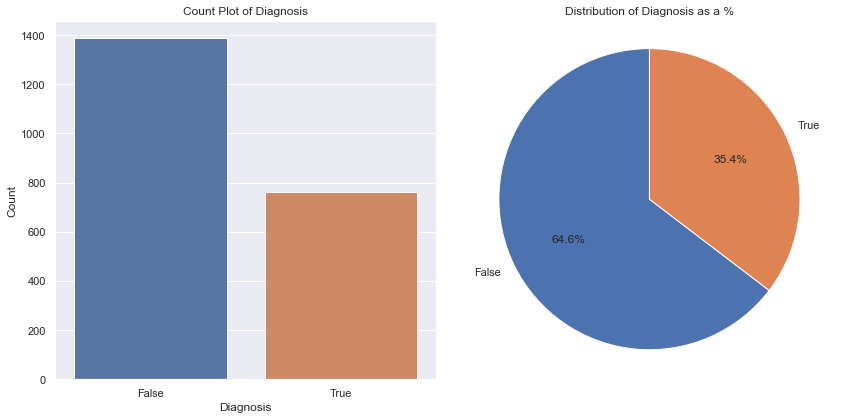

In [14]:
# Plotting the response variable - Diagnosis
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Countplot of Diagnosis using Seaborn
sb.countplot(x='Diagnosis', data=bool_df, ax=axes[0])
axes[0].set_title("Count Plot of Diagnosis")
axes[0].set_xlabel("Diagnosis")
axes[0].set_ylabel("Count")

# Pie chart of Diagnosis
diagnosis_counts = bool_df['Diagnosis'].value_counts()
axes[1].pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].axis('equal')  
axes[1].set_title("Distribution of Diagnosis as a %")

plt.tight_layout()
plt.show()

### Comment:
### Dataset is moderately imbalanced, with about majority (2/3) of Diagnosis for Alzemiers being false (64.6% Diagnosis - False and 35.4% Diagnosis - True). Necessary to take into account this imbalance when doing analysis and modeling. 

### Boolean Variables

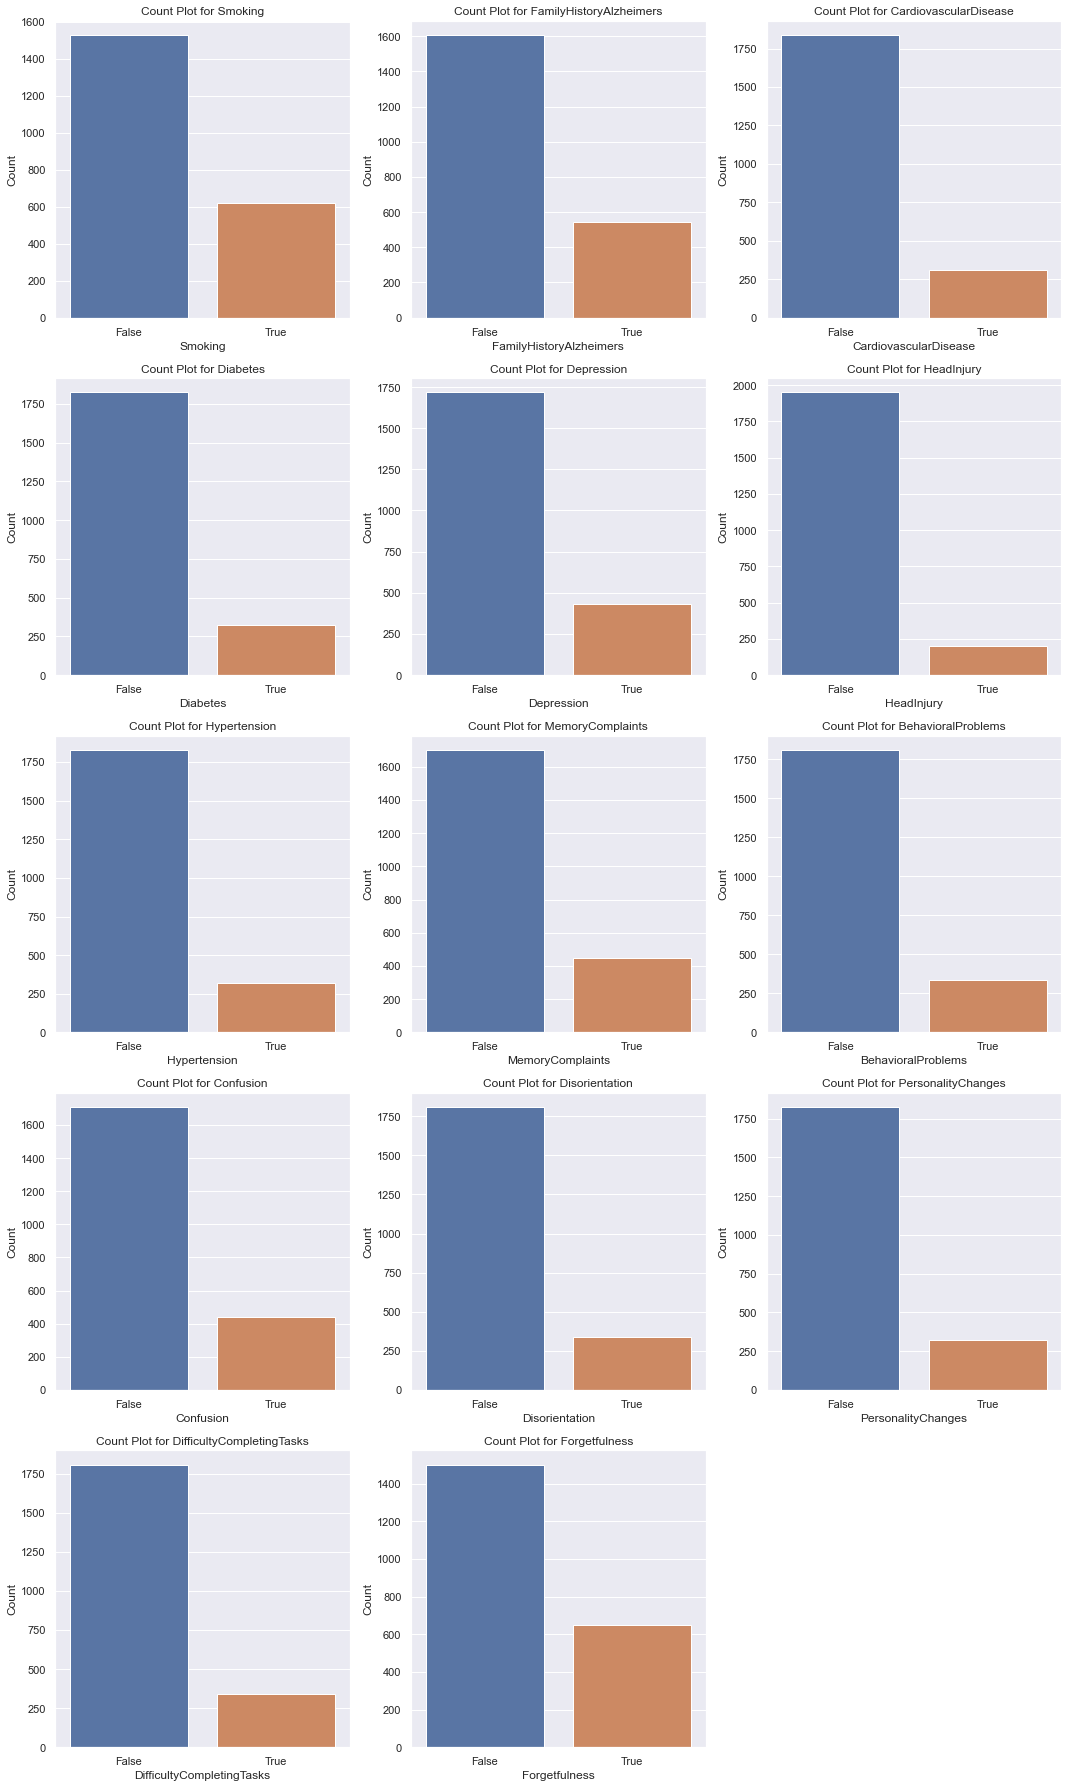

In [56]:
# Exclude 'Diagnosis' from the list of boolean columns to plot
filtered_bool_cols = [col for col in bool_df.columns if col != 'Diagnosis']

# Number of boolean variables to plot
num_vars = len(filtered_bool_cols)
n_cols = 3  
n_rows = math.ceil(num_vars / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten()

# Plot each boolean variable 
for i, col in enumerate(filtered_bool_cols):
    sb.countplot(x=col, data=bool_df, ax=axes[i])
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'Count Plot for {col}')

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comment:
### An imbalance is also observed in the boolean variables where individuals in the dataset appear to be generally healthy with majority indicating false for variables in Lifestyle Factors, Medical History, Cognitive and Functional Assessments and Symptoms. (Number of false much higher than number of true classes)

### 2.1.2 Categorical Data (Countplot)

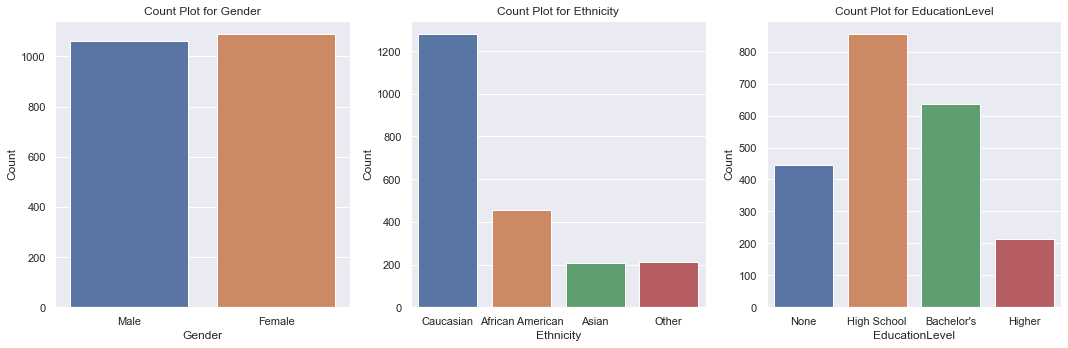

In [44]:
# Define mapping dictionaries for the categorical variables so labels are words instead of numbers
mapping = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Ethnicity': {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'},
    'EducationLevel': {0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'}
}

# Number of categorical variables in cat_df
num_vars = len(cat_df.columns)
n_cols = 3  # Adjust the grid columns as needed
n_rows = math.ceil(num_vars / n_cols)

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axes = axes.flatten()  

# Loop over each categorical column and plot its value counts with proper labels using countplot
for i, col in enumerate(cat_df.columns):
    if col in mapping:
        # Map the numeric codes to descriptive labels
        mapped_col = cat_df[col].map(mapping[col])
        # Define the order based on the mapping dictionary
        order = [mapping[col][key] for key in sorted(mapping[col].keys())
                 if mapping[col][key] in mapped_col.unique()]
        sb.countplot(x=mapped_col, ax=axes[i], order=order)
    else:
        # For columns without a mapping, use the sorted unique values as order ("Gender")
        order = sorted(cat_df[col].unique())
        sb.countplot(x=cat_df[col], ax=axes[i], order=order)
    
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'Count Plot for {col}')

# Remove any unused subplots (if any)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Comment: 
### i) Males and females are equally represented in the dataset, with almost the same number for both.
### ii) The predominant ethnicity is Caucasian, making up more than half of the dataset.
### iii) High School is the Educational Level with the highest numbers, followed closely by Bachelor's

### 2.1.3 Numerical Data (Statistical summary + Boxplot/ Histogram/ Violin plot)

In [45]:
# Print summary statistics for numerical data
print("Summary statistics for numerical data:")
print(num_df.describe())

Summary statistics for numerical data:
               Age          BMI  AlcoholConsumption  PhysicalActivity  \
count  2149.000000  2149.000000         2149.000000       2149.000000   
mean     74.908795    27.655697           10.039442          4.920202   
std       8.990221     7.217438            5.757910          2.857191   
min      60.000000    15.008851            0.002003          0.003616   
25%      67.000000    21.611408            5.139810          2.570626   
50%      75.000000    27.823924            9.934412          4.766424   
75%      83.000000    33.869778           15.157931          7.427899   
max      90.000000    39.992767           19.989293          9.987429   

       DietQuality  SleepQuality   SystolicBP  DiastolicBP  CholesterolTotal  \
count  2149.000000   2149.000000  2149.000000  2149.000000       2149.000000   
mean      4.993138      7.051081   134.264774    89.847836        225.197519   
std       2.909055      1.763573    25.949352    17.592496     

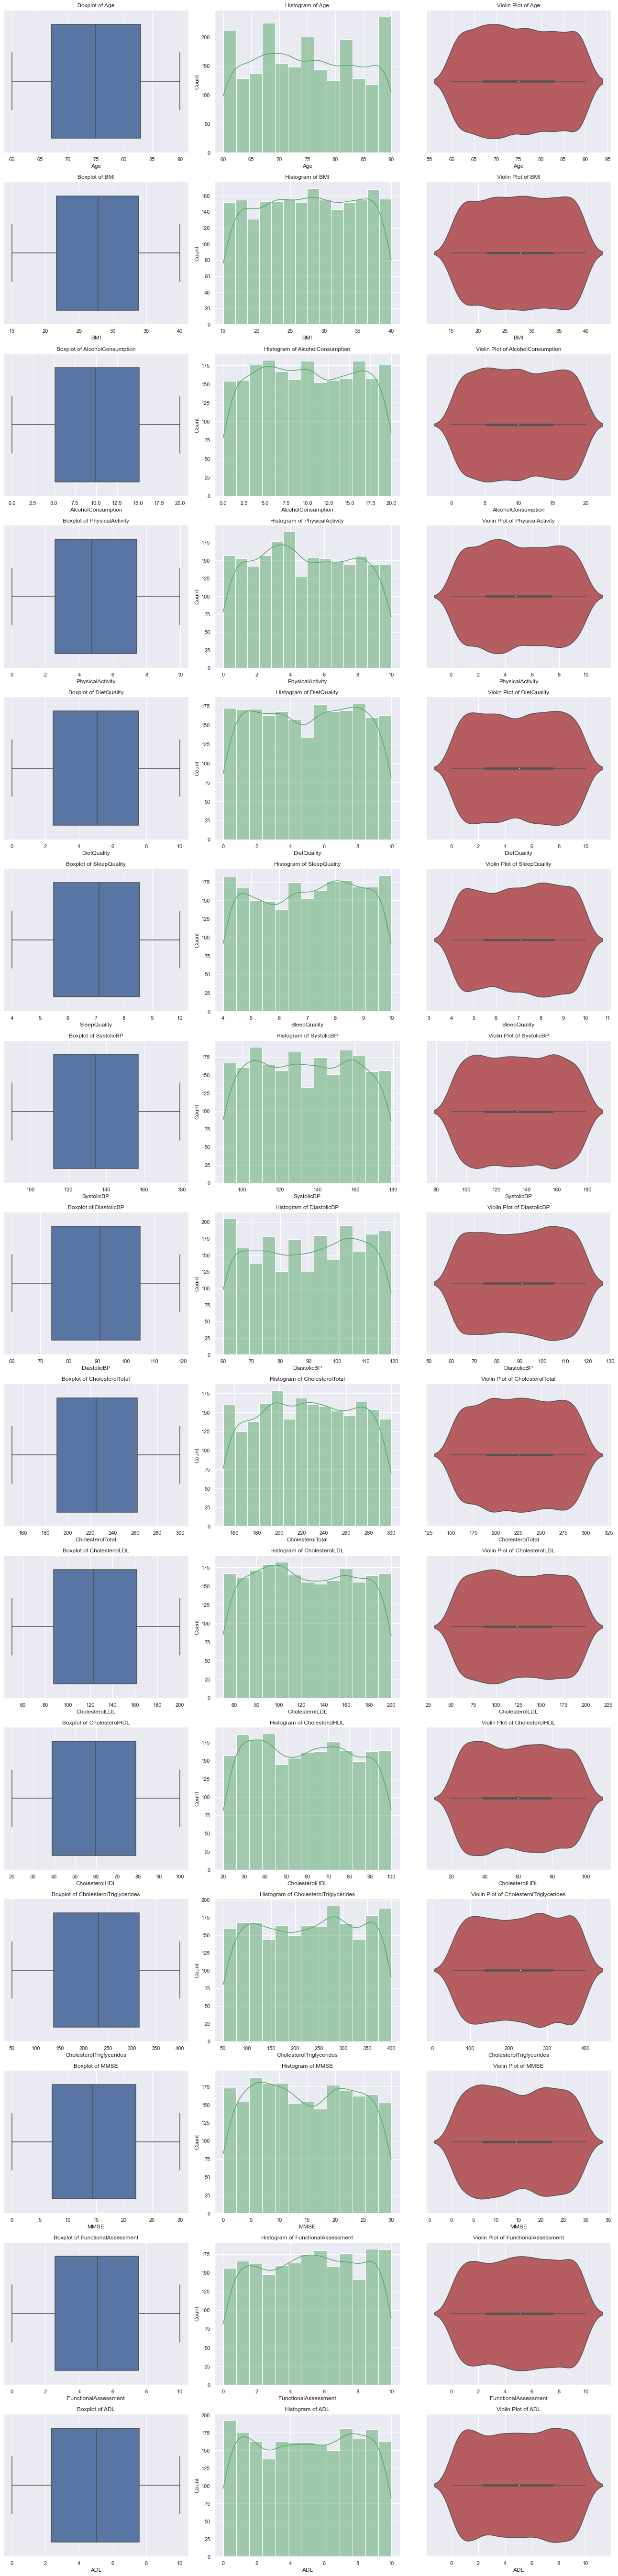

In [46]:
# Determine the number of numerical variables
num_vars = num_df.shape[1]

#Set colour palette for seaborn
sb.set_palette("deep")

# Create subplots: one row per variable, and 3 columns (boxplot, histogram, violin plot)
fig, axes = plt.subplots(num_vars, 3, figsize=(18, 5 * num_vars))

# Loop over each numerical variable and create the plots with different colors
for i, var in enumerate(num_df.columns):
    # Boxplot
    sb.boxplot(x=num_df[var], orient='h', ax=axes[i, 0], color='C0')
    axes[i, 0].set_title(f'Boxplot of {var}')
    
    # Histogram with kernel density estimation
    sb.histplot(num_df[var], kde=True, ax=axes[i, 1], color='C2')
    axes[i, 1].set_title(f'Histogram of {var}')
    
    # Violin plot
    sb.violinplot(x=num_df[var], orient='h', ax=axes[i, 2], color='C3')
    axes[i, 2].set_title(f'Violin Plot of {var}')


plt.tight_layout()
plt.show()

### Comment: 
### i) Most of the numerical features in the dataset show a generally uniform distribution across its range, with dips only at either extremes.
### ii) For MMSE Score, it appears to follow a bi-modal distribution with 2 distinct peaks clustered around 5-10 and 20-25 potentially indicating 2 distinct groups of data. 

## 2.2 Visualize the spread of data in relation to Diagnosis (response variable) i.e if patient has Alzheimer's Disease (Bi-variate)

### 2.2.1 Distribution of Boolean Data by Diagnosis category (countplot)

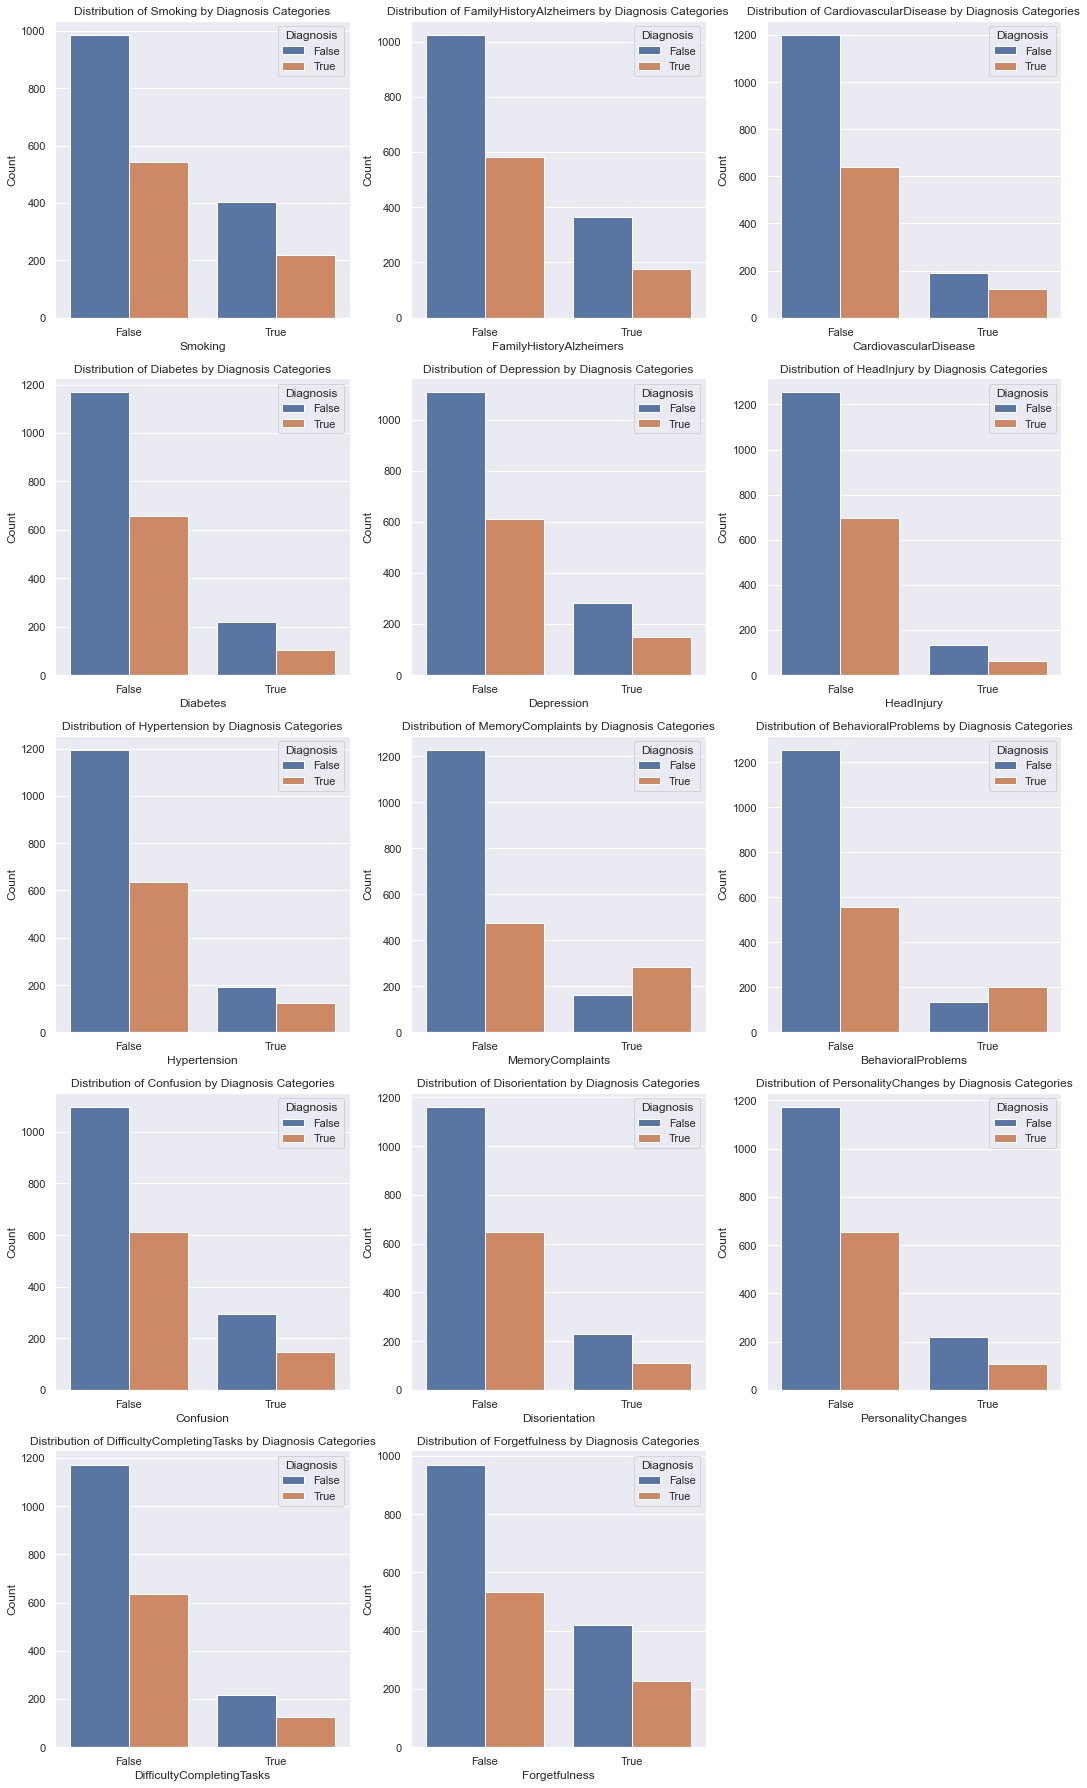

In [47]:
# Filter out "Diagnosis" from bool_cols if it exists (Plotting diagnosis against diagnosis does not provide useful data)
filtered_bool_cols = [col for col in bool_cols if col != 'Diagnosis']

# Set up a grid of subplots based on the filtered boolean columns
n_cols = 3  
n_rows = math.ceil(len(filtered_bool_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharey=False)
axes = axes.flatten()

# Generate a count plot for each remaining boolean column
for i, col in enumerate(filtered_bool_cols):
    sb.countplot(data=bool_df, x=col, hue='Diagnosis', ax=axes[i]) 
    axes[i].set_title(f'Distribution of {col} by Diagnosis Categories')
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Diagnosis')

# Remove any unused subplots (if the total number of filtered columns isn't a multiple of n_cols)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comment: 
### For individuals who have Memory Complaints and Behavioral Problems, the value for Diagnosis - True (with Alzheimer's Disease) is higher than for Diagnosis - False (no Alzheimer's Disease) i.e greater number of individuals with Memory Complaints and Behavioral Problems are diagnosed with Alzheimer's Disease.

### 2.2.2 Distribution of Categorical Data by Diagnosis category (countplot)

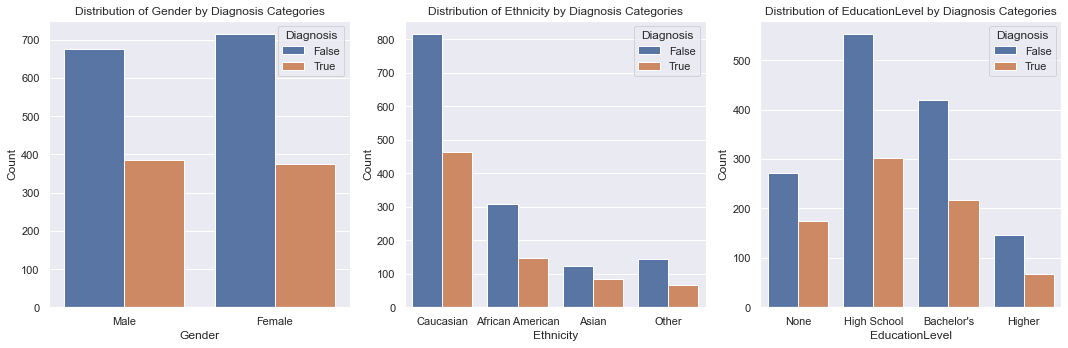

In [48]:
# Define mapping dictionaries for the categorical variables so labels are words instead of numbers
mapping = {
    'Gender': {0: 'Male', 1: 'Female'},
    'Ethnicity': {0: 'Caucasian', 1: 'African American', 2: 'Asian', 3: 'Other'},
    'EducationLevel': {0: 'None', 1: 'High School', 2: "Bachelor's", 3: 'Higher'}
}

# Combine the Diagnosis column with the categorical columns into one DataFrame
cat_visual_df = Alzheimers_DF[['Diagnosis'] + cat_df.columns.tolist()].copy()

# Apply the mappings to each column that appears in the mapping dictionary
for col, map_dict in mapping.items():
    if col in cat_visual_df.columns:
        cat_visual_df[col] = cat_visual_df[col].map(map_dict)

# List of categorical columns (from cat_df)
cat_cols = cat_df.columns

# Set up the grid of subplots
n_cols = 3  
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), sharey=False)
axes = axes.flatten()

# Generate a count plot for each categorical column using cat_visual_df
for i, col in enumerate(cat_cols):
    sb.countplot(data=cat_visual_df, x=col, hue='Diagnosis', ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Diagnosis Categories')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(title='Diagnosis')

# Remove any unused subplots if the total number isnt a multiple of n_cols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Comment: 
### For each class in each category, generally it is observed that the ratio of True to False Diagnosis (for Alzheimer's Disease) is the same, where the number of Diagnosis - False is greater than Diagnosis - True.

### 2.2.3 Distribution of Numeric Data by Diagnosis category (swarmplot)

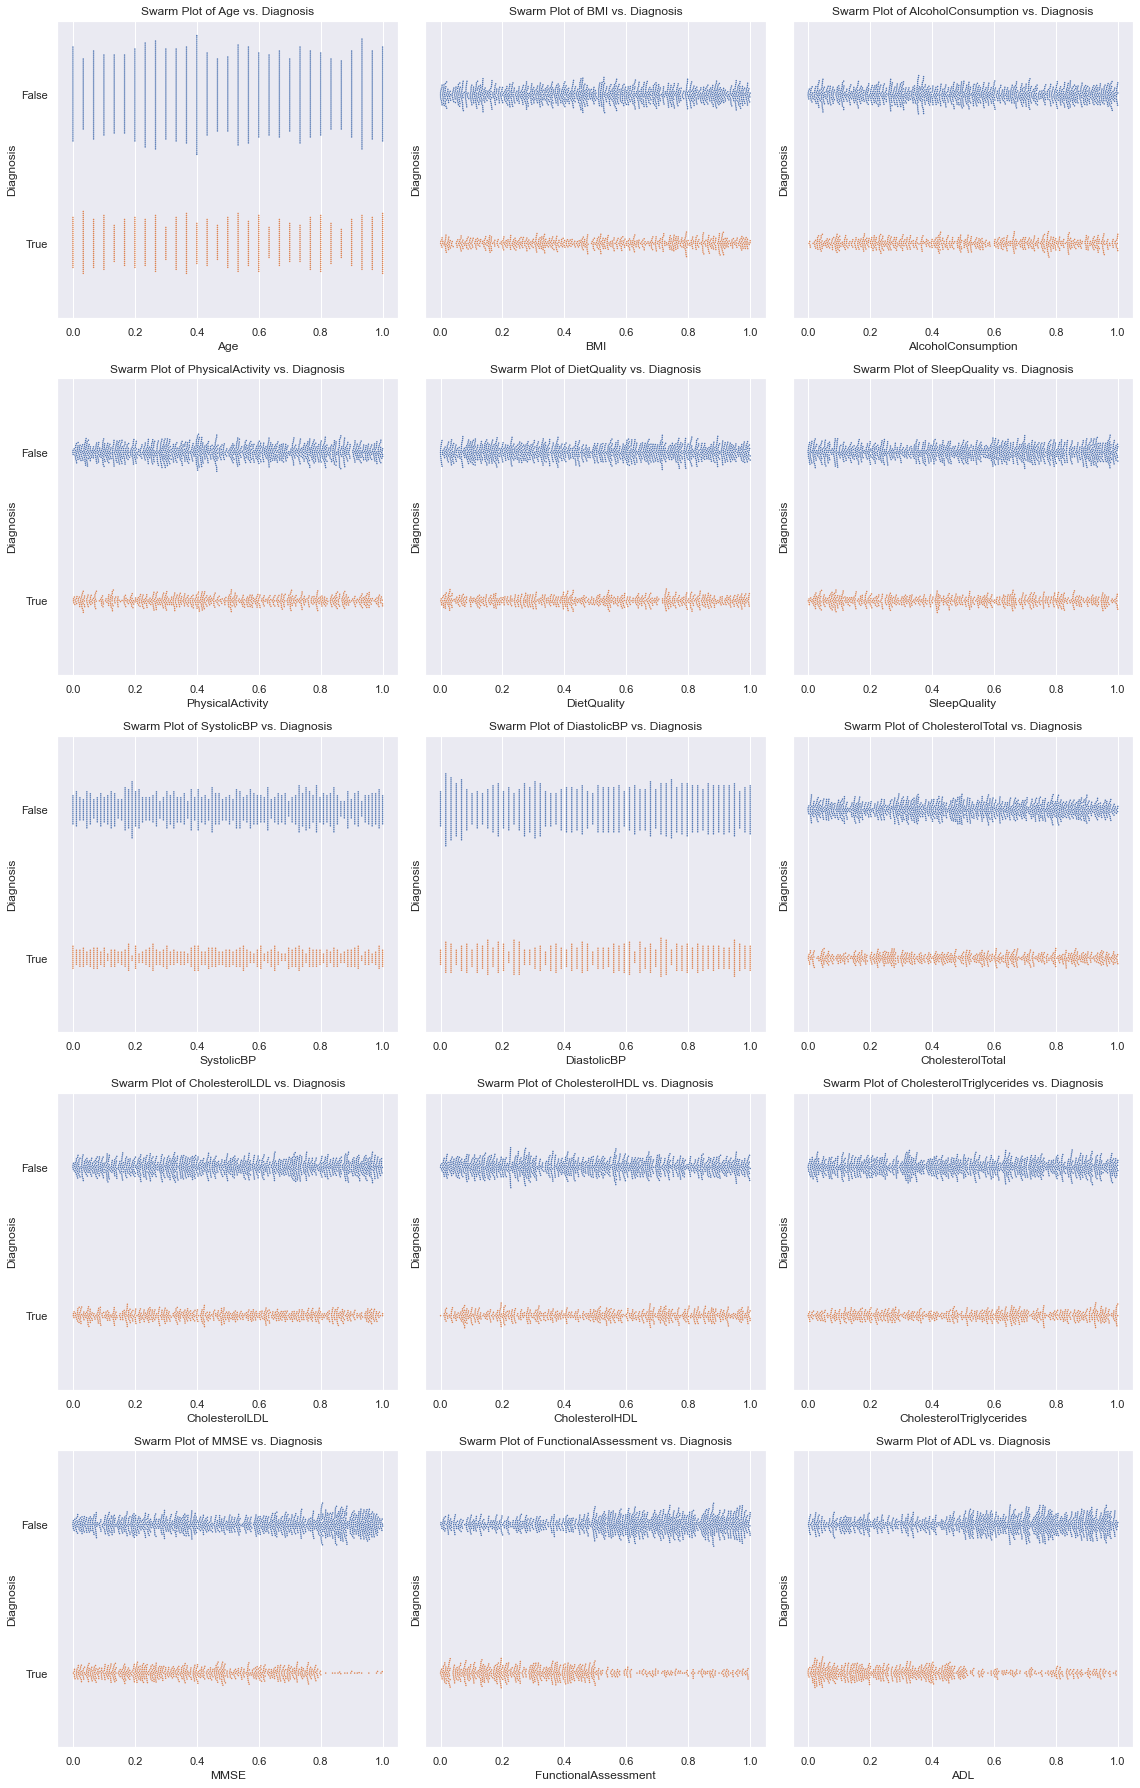

In [57]:
# Combine the Diagnosis column with the numerical columns into one DataFrame
num_visual_df = Alzheimers_DF[['Diagnosis'] + num_df.columns.tolist()].copy()

# List of numeric columns (excluding Diagnosis)
num_cols = num_df.columns

# Determine grid size for subplots
n_vars = len(num_cols)
n_cols = 3  
n_rows = math.ceil(n_vars / n_cols)

# Create the subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows), sharey=True)
axes = axes.flatten() 

# Loop through each numeric column, creating a swarm plot for Diagnosis with reduced marker size
for i, var in enumerate(num_cols):
    sb.swarmplot(
        x=var,
        y='Diagnosis',        # The response variable
        data=num_visual_df,
        orient='h',    
        size=1.5,            
        ax=axes[i]
    )
    axes[i].set_title(f'Swarm Plot of {var} vs. Diagnosis')

# Remove any extra subplots if n_vars doesn't fill the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()   

### Comment: 
### For MMSE, Functional Assessment and ADL, a distinct "cut" or "separation" is observed for the Diagnosis - True and Diagnosis - False swarm plots.
### For MMSE, the cut is observed at ~24.
### For Functional Assessment and ADL, the cut is observed at ~5.
### This could be useful in a decision tree (or related methods) to predict whether an individual is likely to be diagnosed with Alzheimer's Disease.

## 2.3 Exploring Correlation

### 2.3.1 Correlation Matrix of variables against each other (Multi-variate)

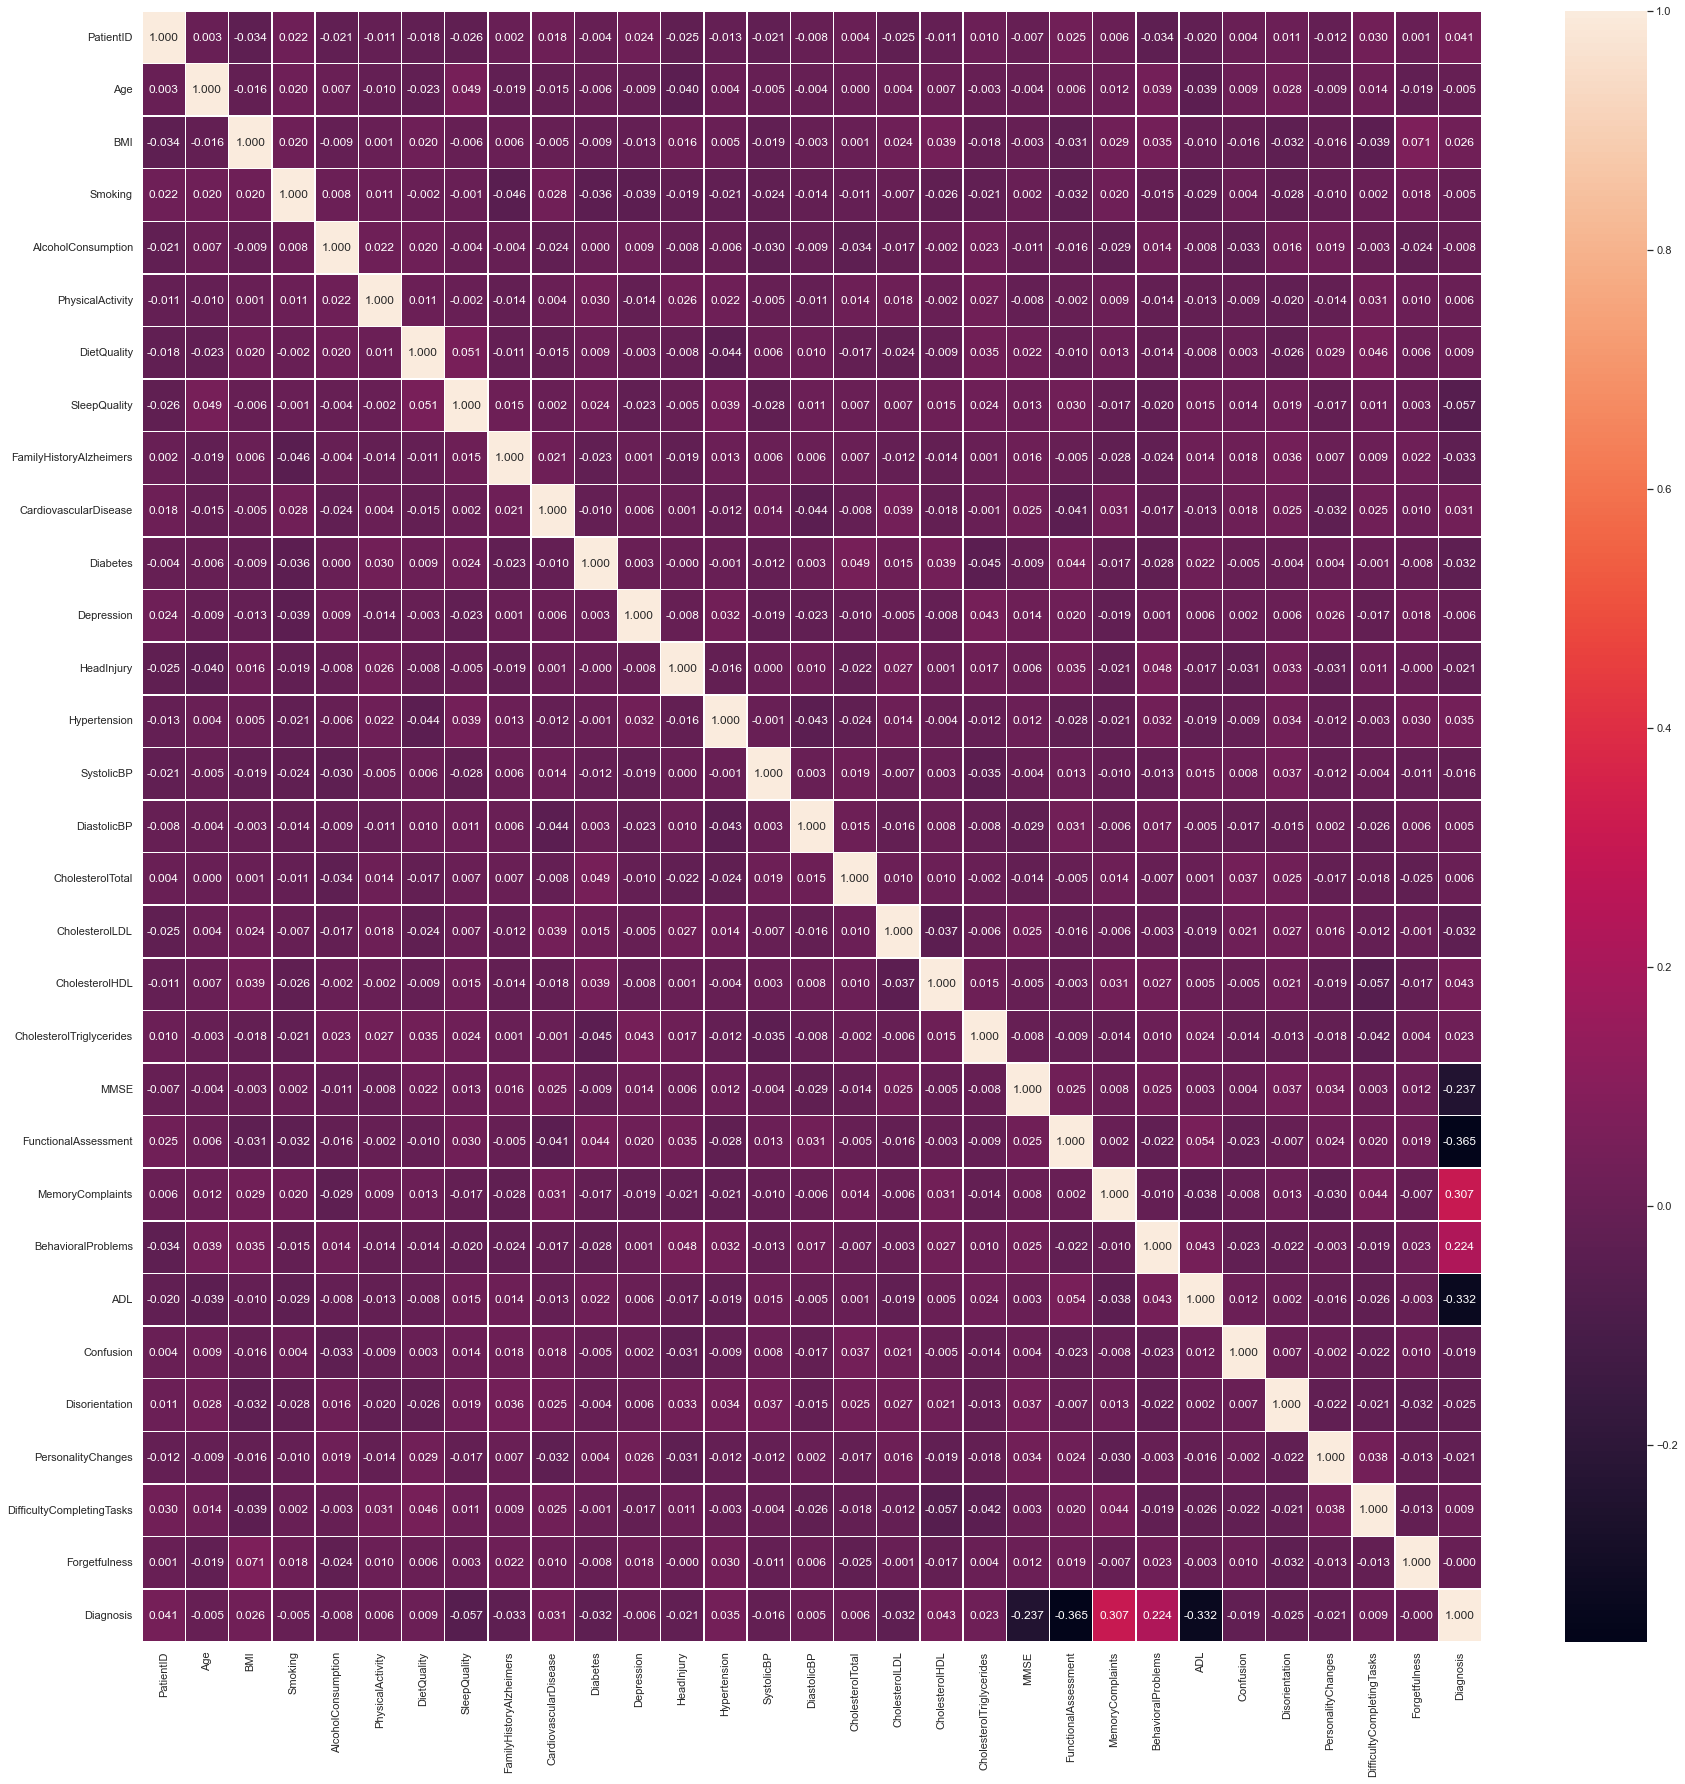

In [50]:
f,ax = plt.subplots(figsize=(30, 30))
sb.heatmap(Alzheimers_DF.corr(), annot=True, linewidths=.5, fmt= '.3f',ax=ax)
plt.show()

### Comment: 
### There is a High Correlation (positive or negative) observed between Diagnosis (response variable) and 5 other variables - MMSE, Functional Assessmnet, Memory Complaints, Behavioral Problems and ADL. (This explained in greater detail in 2.3.2 Section below)
### The Correlation of the remaining variable among themselves is low. However even though this might not be useful in directly predicting likelihood of being diagnosed with Alzheimer's Disease, the interactions between the different variables taken together could yield more accurate prediction models and should not be discarded e.g for neural network

### 2.3.2 Pearson Correlation of Data with Diagnosis 

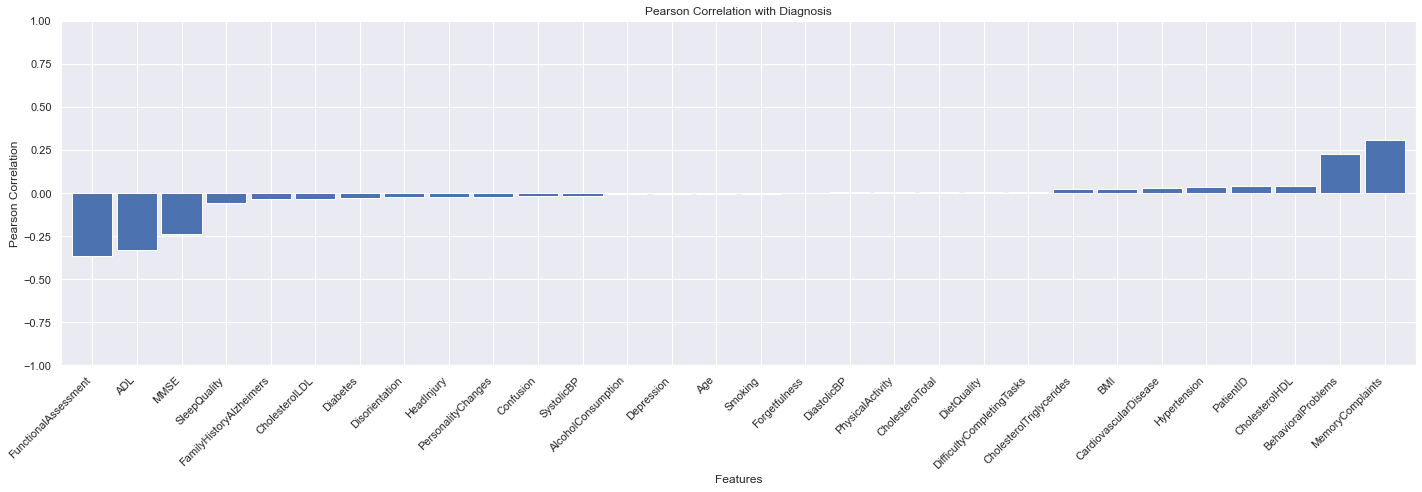

In [58]:
correlations = Alzheimers_DF.corr()['Diagnosis'].drop('Diagnosis').sort_values()

plt.figure(figsize=(20, 7))
ax = correlations.plot(kind='bar', width=0.9)

ax.set(
    ylim=[-1, 1],
    ylabel='Pearson Correlation',
    xlabel='Features',
    title='Pearson Correlation with Diagnosis'
)

ax.set_xticklabels(correlations.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Comment:
### There is relatively high positive correlation to Diagnosis for BehavioralProblems (0.224) and MemoryComplaints (0.307) and negative correlation for FunctionalAssessment (-0.365), ADL (-0.332) and MMSE (-0.237) as compared to the rest of the variables which have little to no correlation. The variables identified with high correlation may be useful in predicting the probability of an individual being diagnosed with Alziemer's disease.

# 3. Prediction Models 

## 3.1 Data Pre-processing (Normalization)

In [15]:
#normalize the columns such that the
columns = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

min_max_scaler = MinMaxScaler()
Alzheimers_DF[columns] = min_max_scaler.fit_transform(Alzheimers_DF[columns])

Alzheimers_DF

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,1,0.433333,0,0,2,0.316960,False,0.665183,0.633375,0.133931,...,0.652102,False,False,0.172486,False,False,False,True,False,False
1,2,0.966667,0,0,0,0.473058,False,0.227170,0.762862,0.050995,...,0.712108,False,False,0.259154,False,False,False,False,True,False
2,3,0.433333,0,3,1,0.111553,False,0.978276,0.785408,0.181896,...,0.589697,False,False,0.711936,False,True,False,True,False,False
3,4,0.466667,1,0,1,0.752163,True,0.610751,0.843804,0.743443,...,0.896823,False,True,0.648094,False,False,False,False,False,False
4,5,0.966667,0,0,0,0.228472,False,0.923204,0.631707,0.078698,...,0.604699,False,False,0.001341,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,2145,0.033333,0,0,1,0.965137,False,0.078006,0.405291,0.655316,...,0.023830,False,False,0.449224,True,False,False,False,False,True
2145,2146,0.500000,0,0,2,0.114035,False,0.938860,0.135925,0.289848,...,0.869049,False,True,0.920508,False,False,False,False,False,True
2146,2147,0.566667,0,0,1,0.018717,False,0.229779,0.989841,0.811960,...,0.197246,False,False,0.503582,False,False,False,False,False,True
2147,2148,0.600000,1,3,1,0.011650,False,0.433901,0.636096,0.125543,...,0.517550,False,False,0.378469,False,False,False,False,True,True


### Comment:
### By normalizing data we ensure that each feature is on a comparable scale, preventing variables with extreme values or ranges from skewing the training models.

## 3.2 Splitting Data into Training and Testing Sets

In [16]:
#split data into features and target
X = Alzheimers_DF.drop(columns = ['Diagnosis'])
y = Alzheimers_DF['Diagnosis']

#split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 42, shuffle = True)

### Comment:
### Since our dataset is moderately sized (2000+ entries), we chose to split training and test set in a 70% to 30% ratio to ensure there is sufficient test data.

## 3.3 Tree-based Classification Models

## 3.3.1 Decision Tree

## 3.3.1.1 Find the optimal max depth for decision tree using GridCV search, optimized based on Accuracy, Area Under ROC Curve (AUC-ROC) and Area Under Precision-Recall Curve(AUC-PR)

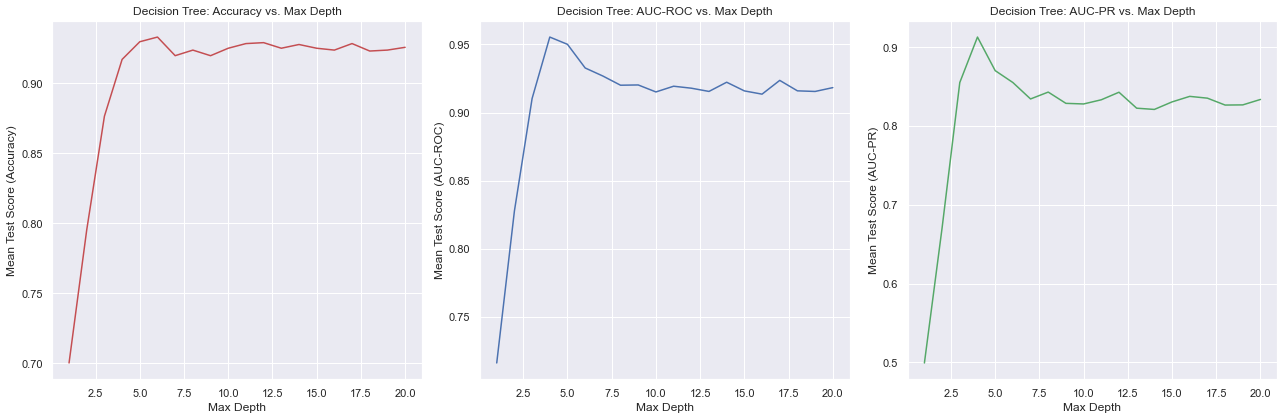

In [54]:
# Define the range of max_depth values to search
param_grid = {'max_depth': range(1, 21)}

# Initialize the Decision Tree classifier
dt = DecisionTreeClassifier()

# GridSearchCV for Accuracy
grid_search_acc = GridSearchCV(estimator=dt, param_grid=param_grid, 
                               cv=5, scoring='accuracy')
grid_search_acc.fit(X_train, y_train)

# GridSearchCV for AUC-ROC
grid_search_auc = GridSearchCV(estimator=dt, param_grid=param_grid, 
                               cv=5, scoring='roc_auc')
grid_search_auc.fit(X_train, y_train)

# GridSearchCV for AUC-PR
grid_search_pr = GridSearchCV(estimator=dt, param_grid=param_grid, 
                              cv=5, scoring='average_precision')
grid_search_pr.fit(X_train, y_train)

# Extract results from grid search for each metric
results_auc = grid_search_auc.cv_results_
results_pr = grid_search_pr.cv_results_
results_acc = grid_search_acc.cv_results_

# Plot the performance of max_depth for AUC-ROC, AUC-PR, and Accuracy
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot Accuracy
axs[0].plot(results_acc['param_max_depth'], results_acc['mean_test_score'], label='Accuracy', color='r')
axs[0].set_xlabel('Max Depth')
axs[0].set_ylabel('Mean Test Score (Accuracy)')
axs[0].set_title('Decision Tree: Accuracy vs. Max Depth')
axs[0].grid(True)

# Plot AUC-ROC
axs[1].plot(results_auc['param_max_depth'], results_auc['mean_test_score'], label='AUC-ROC', color='b')
axs[1].set_xlabel('Max Depth')
axs[1].set_ylabel('Mean Test Score (AUC-ROC)')
axs[1].set_title('Decision Tree: AUC-ROC vs. Max Depth')
axs[1].grid(True)

# Plot AUC-PR (Area Under Precision-Recall Curve)
axs[2].plot(results_pr['param_max_depth'], results_pr['mean_test_score'], label='AUC-PR', color='g')
axs[2].set_xlabel('Max Depth')
axs[2].set_ylabel('Mean Test Score (AUC-PR)')
axs[2].set_title('Decision Tree: AUC-PR vs. Max Depth')
axs[2].grid(True)

# Display the plots
plt.tight_layout()
plt.show()

### Comment
### We use GridSearchCV to exhaustively search for the Max Depth from 1 to 21. As observed from the graph, best Max Depth is between 4 and 5 (it is smallest depth with highest score across the 3 metrics i.e "left elbow" of the graphs). By trial and error, we determine 5 is the better max depth.  We do not take higher values of max depth to reduce chance of overfitting. 

## 3.3.1.2 Create decision tree with Max Depth 5 using train set and apply to Test Set. Plot the confusion matrix, ROC and PR Curves as well as print Accuracy, F0.5, F1, F2, AUC-ROC and AUC-PR metrics.

Decision Tree diagram:


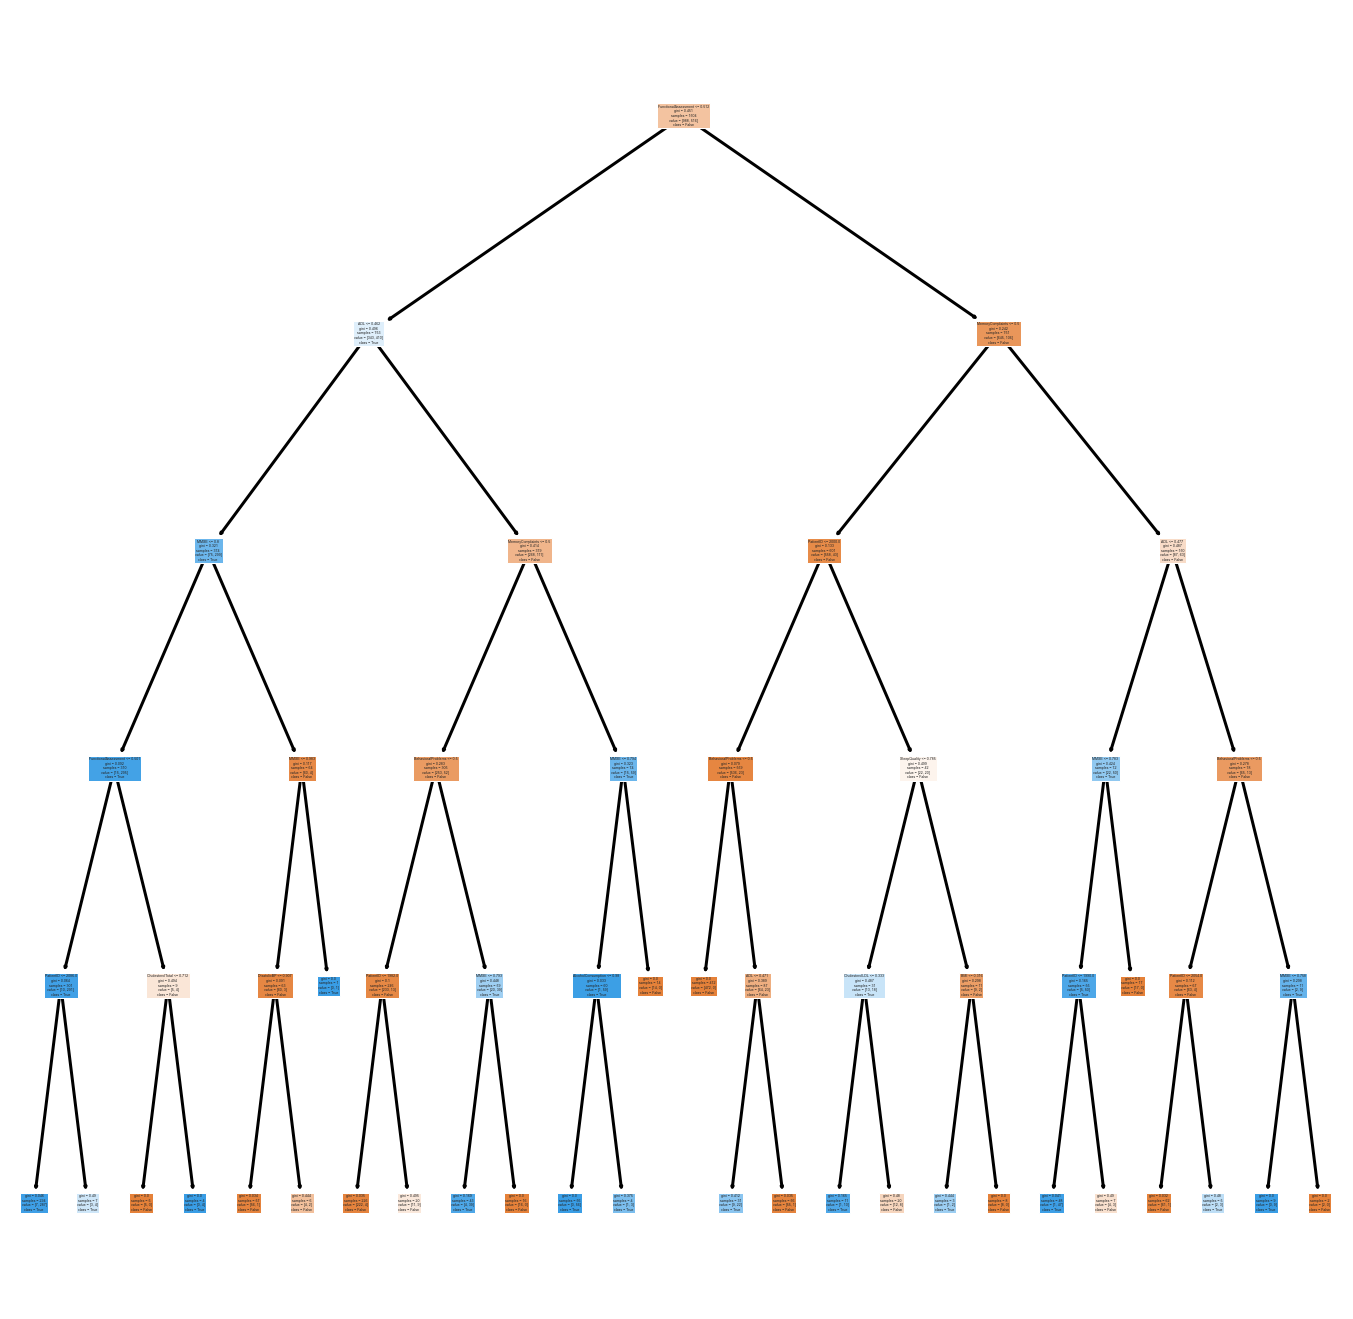

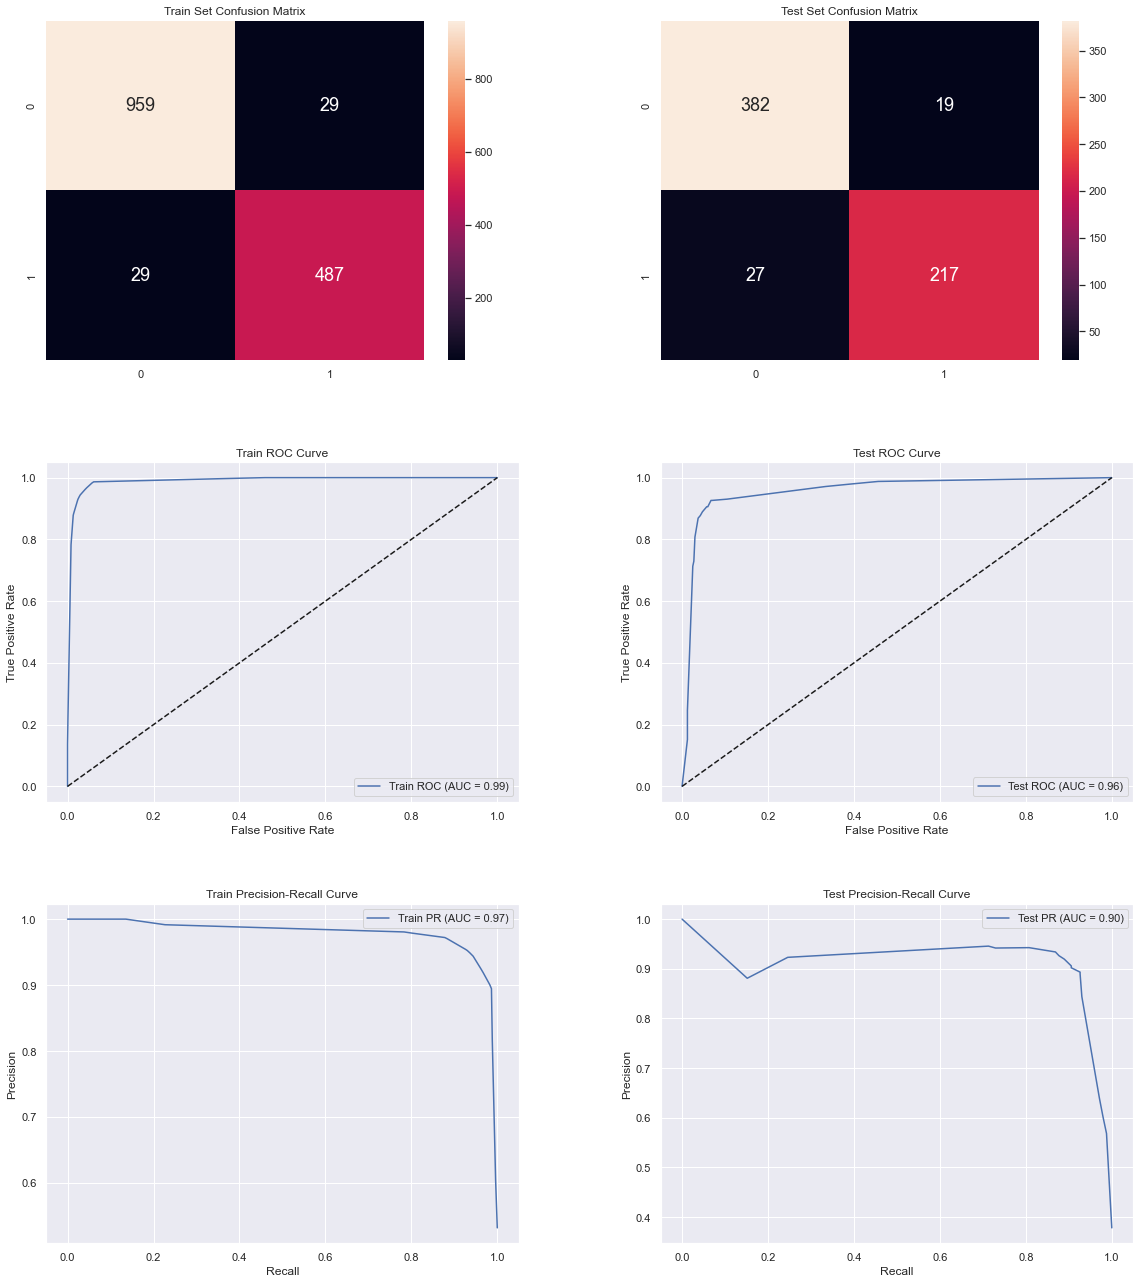

+------------------------------------------------------------------+
|             Model Evaluation Metrics (Decision Tree)             |
+--------------------------+-------------------+-------------------+
| Goodness of Fit of Model |     Train Dataset |      Test Dataset |
+--------------------------+-------------------+-------------------+
|         Accuracy         | 0.961436170212766 | 0.928682170542636 |
|         AUC ROC          | 0.989719659165804 | 0.956594170311925 |
|          AUC PR          | 0.973963671191328 | 0.904621031241926 |
|         F1 Score         | 0.943798449612403 | 0.904166666666667 |
|        F0.5 Score        | 0.943798449612403 | 0.913299663299663 |
|         F2 Score         | 0.943798449612403 | 0.895214521452145 |
+--------------------------+-------------------+-------------------+


In [59]:
# Applying Decision Tree
# Create a Decision Tree Classifier object
dectree = DecisionTreeClassifier(max_depth = 5)

# Train the Decision Tree Classifier model
dectree.fit(X_train, y_train)

# Predict
y_train_pred = dectree.predict(X_train)
y_test_pred = dectree.predict(X_test)

# Calculation of metrics
# Accuracy for Train and Test
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate F0.5 Score for Train and Test
train_f05 = fbeta_score(y_train, y_train_pred, beta=0.5)
test_f05 = fbeta_score(y_test, y_test_pred, beta=0.5)

# Calculate F1 Score for Train and Test
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Calculate F2 Score for Train and Test
train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)

# ROC Curve (with thresholds) for Train and Test
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, dectree.predict_proba(X_train)[:, 1])
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, dectree.predict_proba(X_test)[:, 1])

# Precision-Recall Curve (with thresholds) for Train and Test
precision_train, recall_train, pr_thresholds_train = precision_recall_curve(y_train, dectree.predict_proba(X_train)[:, 1])
precision_test, recall_test, pr_thresholds_test = precision_recall_curve(y_test, dectree.predict_proba(X_test)[:, 1])

# Calculate AUC for Train and Test
train_auc = auc(fpr_train, tpr_train)
test_auc = auc(fpr_test, tpr_test)

# Calculate AUC-PR for Train and Test
train_auc_pr = average_precision_score(y_train, dectree.predict_proba(X_train)[:, 1])
test_auc_pr = average_precision_score(y_test, dectree.predict_proba(X_test)[:, 1])

# Plot decision tree
print("Decision Tree diagram:")
fig, ax = plt.subplots(figsize=(24, 24))
out = plot_tree(dectree, 
          feature_names = X_train.columns.tolist(),
          class_names = [str(x) for x in dectree.classes_],
          filled=True)

for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor('black')
        arrow.set_linewidth(3)
        
plt.show()

# Plot curves
# Create a 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(16, 18))

# Plot Confusion Matrix - First row
axs[0, 0].set_title("Train Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 0])
axs[0, 1].set_title("Test Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 1])

# ROC Curve - Second row
axs[1, 0].plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.2f})')
axs[1, 0].plot([0, 1], [0, 1], 'k--')
axs[1, 0].set_xlabel('False Positive Rate')
axs[1, 0].set_ylabel('True Positive Rate')
axs[1, 0].set_title('Train ROC Curve')
axs[1, 0].legend(loc="lower right")

# Plot ROC Curve (Test)
axs[1, 1].plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.2f})')
axs[1, 1].plot([0, 1], [0, 1], 'k--')
axs[1, 1].set_xlabel('False Positive Rate')
axs[1, 1].set_ylabel('True Positive Rate')
axs[1, 1].set_title('Test ROC Curve')
axs[1, 1].legend(loc="lower right")

# PR Curve - Third row
axs[2, 0].plot(recall_train, precision_train, label=f'Train PR (AUC = {train_auc_pr:.2f})')
axs[2, 0].set_xlabel('Recall')
axs[2, 0].set_ylabel('Precision')
axs[2, 0].set_title('Train Precision-Recall Curve')
axs[2, 0].legend()

# Test Precision-Recall Curve
axs[2, 1].plot(recall_test, precision_test, label=f'Test PR (AUC = {test_auc_pr:.2f})')
axs[2, 1].set_xlabel('Recall')
axs[2, 1].set_ylabel('Precision')
axs[2, 1].set_title('Test Precision-Recall Curve')
axs[2, 1].legend()

# Adjust layout for uniform spacing
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3) 
plt.show()

# Create the table
table = PrettyTable()

# Set title and column headers
table.title = "Model Evaluation Metrics (Decision Tree)"
table.field_names = ["Goodness of Fit of Model", "Train Dataset", "Test Dataset"]

# Add rows with your metrics
table.add_row(["Accuracy", f"{train_accuracy:.15f}", f"{test_accuracy:.15f}"])
table.add_row(["AUC ROC", f"{train_auc:.15f}", f"{test_auc:.15f}"])
table.add_row(["AUC PR", f"{train_auc_pr:.15f}", f"{test_auc_pr:.15f}"])
table.add_row(["F1 Score", f"{train_f1:.15f}", f"{test_f1:.15f}"])
table.add_row(["F0.5 Score", f"{train_f05:.15f}", f"{test_f05:.15f}"])
table.add_row(["F2 Score", f"{train_f2:.15f}", f"{test_f2:.15f}"])

# Right align
table.align["Train Dataset"] = "r"
table.align["Test Dataset"] = "r"

# Print the table
print(table)

### Comment:
### We have a few  Model Evaluation Metrics for decision tree. We will now discuss how suited these metrics are in our evaluating classification models.

### i) The accuracy of the model for both train and test set may appear to be great at about 0.9614 and 0.9286 for train and test set respectively. However, accuracy can be misleading for model evaluation as the dataset is imbalanced, with more negative cases i.e Diagnosis - False as compared to Diagnosis - True for Alzheimer's disease and should be avoided. This is because the model could simply predict only the majority class (Diagnosis - False) and still achieve a high accuracy, without identifying minority class (Diagnosis - True).

### ii) ROC curve plots True Positive Rate (Recall, Sensitivity) vs. False Positive Rate (1 - Specificity) across different classification thresholds while the PR curve plots Precision (Positive Predictive Value) vs. Recall (True Positive Rate) across different classification thresholds for the model. The classification threshold determines whether a predicted probability (for a row in the test set) is classified as Diagnosis - True or Diagnosis - False. The curves themselves as well as the area under each curve serve as useful metrics for model evaluation as explained below.

### While AUC ROC is useful in measuring the model's ability to discriminate between classes i.e Diagnosis - False or Diagnosis - True, it is more suited towards balanced datasets and data sets where both response classes matter equally as compared to AUC PR. AUC PR focuses more on the performance of the model with respect to the minority class (Diagnosis - True) in terms of how reliable positive predictions are and hence is better for our dataset which is imbalanced and where misclassifying the minority class (Diagnosis - True) i.e false negatives would be very costly. For Alzheimer's Disease diagnosis, failure to detect the disease in time could cause a patient to suffer a great loss of living standard due to the lack of early intervention and treatment. Therefore we will focus on AUC PR as a metric for optimizing our models.

### iii) F-scores are weighted harmonic means of precision and recall (combine precision and recall) at a specific threshold value (0.5 by default) and are useful in evaluating classification models, especially for imbalanced datasets. They are controlled by β parameter which determines how precision and recall are weighted. 

### In general:
**Recall formula:**  
$$
\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}
$$

**Precision formula:**  
$$
\text{Precision} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Positives (FP)}}
$$

**The general F-score (Fβ) formula:**  
$$
F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{(\beta^2 \cdot \text{Precision}) + \text{Recall}}
$$

### For specific F-scores: 
**F1 Score (Balanced):**
$$
F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

**F0.5 Score (Precision-Weighted):**
$$
F_{0.5} = 1.25 \cdot \frac{\text{Precision} \cdot \text{Recall}}{(0.25 \cdot \text{Precision}) + \text{Recall}}
$$

**F2 Score (Recall-Weighted):**
$$
F_2 = 5 \cdot \frac{\text{Precision} \cdot \text{Recall}}{(4 \cdot \text{Precision}) + \text{Recall}}
$$

**How F score impacts the balance on Precision and Recall**

| F-Score  | Emphasis                          | Cost Preference           | β Relationship      |
|:--------:|:----------------------------------:|:-------------------------:|:-------------------:|
| **F1**   | Balanced                          | Balance FP and FN         | β = 1               |
| **F0.5** | Precision > Recall (Favors Precision) | Avoid false positives     | β < 1 (e.g., 0.5)   |
| **F2**   | Recall > Precision (Favors Recall) | Avoid false negatives     | β > 1 (e.g., 2)     |

### For our Alzheimer's disease classification models, prioritizing recall over precision is clinically essential (by using F2 score instead of F1 or F0.5). It is vital to minimize false negatives (missed diagnoses) even if it means accepting more false positives (over-diagnosis). False negatives can result in an individual missing a critical treatment window resulting in permanent loss in brain function/quality of life. But false positives do no harm and can be corrected through follow-up testing. As such we will focus on F2 score as a metric for evaluating our models.

### Note that the F2 score (or F score in general) is impacted by the classification threshold. The above F2 score in the table is based on the default threshold value of 0.5. We should determine the optimal threshold value for the corresponding maximum F2 score as a metric for comparison. We can do this by plotting the F scores against threshold value and finding the maximum F2 score and its corresponding threshold value. We will do this in the next section.

## 3.3.1.3 Plot F-score against threshold value and indicate on PR Curve plot to determine maximum F2 score and corresponding recall-optimized threshold value

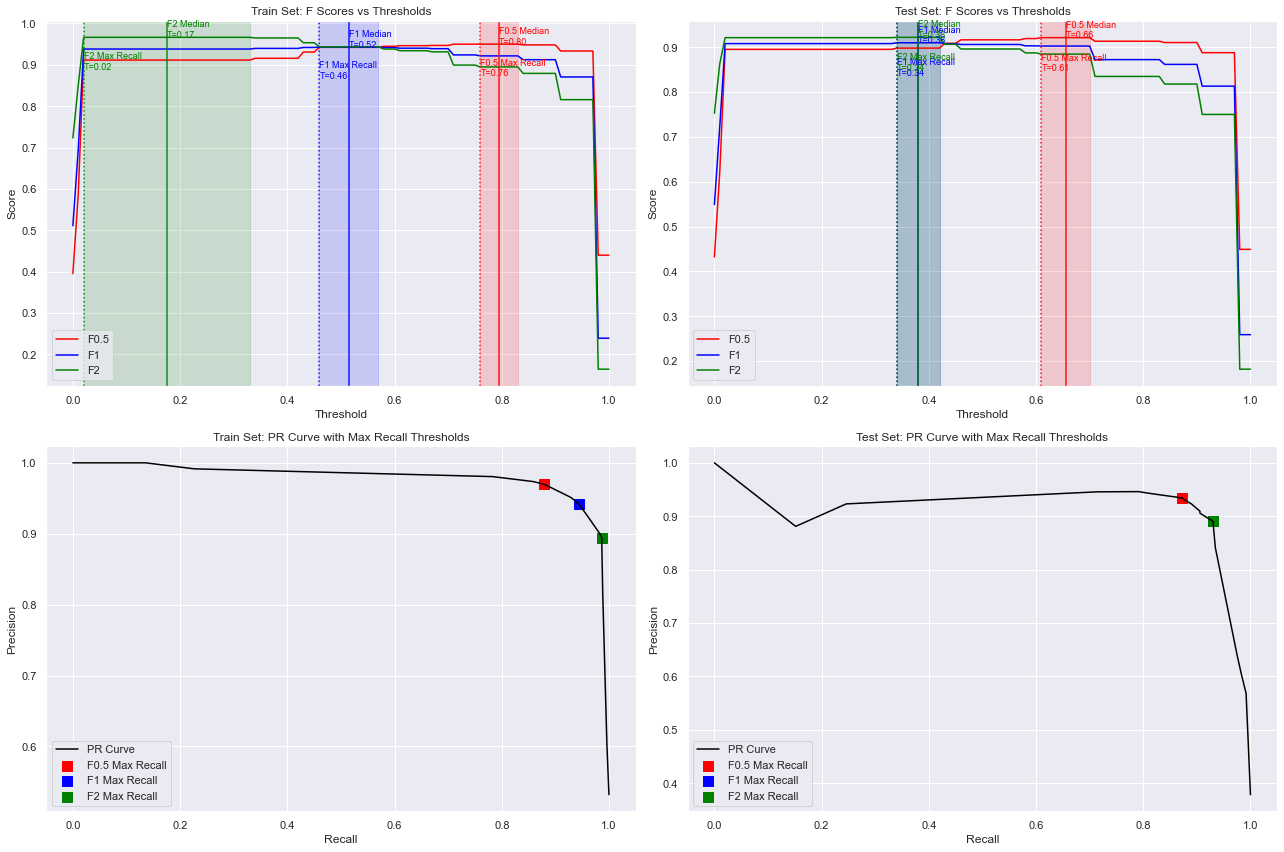

Maximum F2 Scores optimized for recall (Decision Tree)
Train Set: 0.9666 at threshold 0.02
Test Set: 0.9220 at threshold 0.34


In [62]:
# Train classifier
dectree = DecisionTreeClassifier(max_depth=5)
dectree.fit(X_train, y_train)

# Predict probabilities
y_train_proba = dectree.predict_proba(X_train)[:, 1]
y_test_proba = dectree.predict_proba(X_test)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0, 1.01, 0.01)

# Calculate F scores
def calculate_metrics(y_true, y_proba, thresholds):
    f1, f2, f05 = [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1.append(f1_score(y_true, y_pred, zero_division=0))
        f2.append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))
        f05.append(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0))
    return f1, f2, f05

# Analyze F-score peak thresholds
def get_threshold_analysis(y_true, y_proba, thresholds, scores):
    max_score = max(scores)
    matching = [t for t, s in zip(thresholds, scores) if s == max_score]

    best_rec = -1
    best_t_rec = None

    for t in matching:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec > best_rec:
            best_rec = rec
            best_t_rec = t

    return {
        "min": min(matching),
        "max": max(matching),
        "median": np.median(matching),
        "best_recall": best_t_rec,
        "max_score": max_score
    }

# PR point from threshold
def find_pr_point(probs, y_true, threshold):
    y_pred = (probs >= threshold).astype(int)
    return recall_score(y_true, y_pred, zero_division=0), precision_score(y_true, y_pred, zero_division=0)

# Calculate scores
train_f1, train_f2, train_f05 = calculate_metrics(y_train, y_train_proba, thresholds)
test_f1, test_f2, test_f05 = calculate_metrics(y_test, y_test_proba, thresholds)

# Get ranges
train_ranges = {
    "F0.5": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f05),
    "F1": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f1),
    "F2": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f2),
}

test_ranges = {
    "F0.5": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f05),
    "F1": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f1),
    "F2": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f2),
}

# PR curves
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
colors = {'F0.5': 'red', 'F1': 'blue', 'F2': 'green'}

# --- Train: F scores vs Threshold ---
axs[0, 0].plot(thresholds, train_f05, label='F0.5', color=colors['F0.5'])
axs[0, 0].plot(thresholds, train_f1, label='F1', color=colors['F1'])
axs[0, 0].plot(thresholds, train_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = train_ranges[label]
    c = colors[label]
    axs[0, 0].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 0].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 0].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 0].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 0].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 0].set_title('Train Set: F Scores vs Thresholds')
axs[0, 0].set_xlabel('Threshold')
axs[0, 0].set_ylabel('Score')
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Test: F scores vs Threshold ---
axs[0, 1].plot(thresholds, test_f05, label='F0.5', color=colors['F0.5'])
axs[0, 1].plot(thresholds, test_f1, label='F1', color=colors['F1'])
axs[0, 1].plot(thresholds, test_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = test_ranges[label]
    c = colors[label]
    axs[0, 1].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 1].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 1].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 1].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 1].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 1].set_title('Test Set: F Scores vs Thresholds')
axs[0, 1].set_xlabel('Threshold')
axs[0, 1].set_ylabel('Score')
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- Train PR Curve --- 
axs[1, 0].plot(recall_train, precision_train, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_train_proba, y_train, train_ranges[label]['best_recall'])
    axs[1, 0].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 0].set_title('Train Set: PR Curve with Max Recall Thresholds')
axs[1, 0].set_xlabel('Recall')
axs[1, 0].set_ylabel('Precision')
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- Test PR Curve --- 
axs[1, 1].plot(recall_test, precision_test, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_test_proba, y_test, test_ranges[label]['best_recall'])
    axs[1, 1].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 1].set_title('Test Set: PR Curve with Max Recall Thresholds')
axs[1, 1].set_xlabel('Recall')
axs[1, 1].set_ylabel('Precision')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


# Print out max F2 scores
print("Maximum F2 Scores optimized for recall (Decision Tree)")
print(f"Train Set: {max(train_f2):.4f} at threshold {train_ranges['F2']['best_recall']:.2f}")
print(f"Test Set: {max(test_f2):.4f} at threshold {test_ranges['F2']['best_recall']:.2f}")


### Comment:
### F2 score for train and test set at an optimized threshold is higher than at default threshold of 0.5 in section 3.3.1.3 (0.9666 vs 0.9437 and 0.9220 vs 0.8952 for train and test respectively). (This tends to be true in general for other models.) As seen from the F score threshold graph, there may be a range of threshold values for which the F2 score is a maximum. However, for the same maximum F2 score, the ratio of Recall and Precision might differ. See cases A, B and C below

| Case | Precision | Recall | F2 Score | Tradeoff Description                          |
|------|-----------|--------|----------|-----------------------------------------------|
| A    | 0.64      | 1.00   | 0.80     | Maximizes recall at the cost of more false positives |
| B    | 0.80      | 0.80   | 0.80     | Balanced tradeoff between precision and recall |
| C    | 1.00      | 0.64   | 0.80     | Maximizes precision at the cost of more false negatives |

### Therefore, for the same F2 score, we should optimize the threshold such that recall is maximized (explained earlier above). This is seen in the graph (left hand side/left hand limit of the range of threshold for F2). The optimized threshold are 0.02 and 0.34 for train and test set respectively.

# **We will repeat the above steps for the other classification models to find the F2 Max and other relevant metrics so as to be able to compare suitability and effectiveness of each model.

## 3.3.2 Decision Tree Boosting (GradientBoost)

## 3.3.2.1 Find the optimal hyperparameters using bayesian optimization, optimized based on Area Under Precision-Recall Curve (AUC-PR)

In [34]:
def objective(trial):
    # Suggest hyperparameters
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    n_estimators = trial.suggest_int("n_estimators", 100, 500)
    max_depth = trial.suggest_int("max_depth", 1, 3)
    subsample = trial.suggest_float("subsample", 0.7, 1.0)
    min_samples_split = trial.suggest_int("min_samples_split", 10, 20)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 5, 20)

    # Create and train model
    model = GradientBoostingClassifier(
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        max_depth=max_depth,
        subsample=subsample,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=52
    )

    model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = model.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, y_pred)

    return auc_pr

# Set up and run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

# Output best results
print("Best Hyperparameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")

print(f"\nBest AUC-PR Score: {study.best_value}")

[I 2025-04-14 19:51:39,126] A new study created in memory with name: no-name-9b6db8a3-d088-4766-86e5-2a411e83f49e
[I 2025-04-14 19:51:39,654] Trial 0 finished with value: 0.900087892834315 and parameters: {'learning_rate': 0.08769524649752146, 'n_estimators': 282, 'max_depth': 1, 'subsample': 0.8154408933872748, 'min_samples_split': 14, 'min_samples_leaf': 19}. Best is trial 0 with value: 0.900087892834315.
[I 2025-04-14 19:51:40,491] Trial 1 finished with value: 0.9287482259444579 and parameters: {'learning_rate': 0.014948901480867754, 'n_estimators': 295, 'max_depth': 2, 'subsample': 0.711366979019835, 'min_samples_split': 16, 'min_samples_leaf': 17}. Best is trial 1 with value: 0.9287482259444579.
[I 2025-04-14 19:51:41,117] Trial 2 finished with value: 0.9083703140888439 and parameters: {'learning_rate': 0.05032787057659976, 'n_estimators': 304, 'max_depth': 1, 'subsample': 0.8435194874656133, 'min_samples_split': 18, 'min_samples_leaf': 10}. Best is trial 1 with value: 0.928748225

Best Hyperparameters:
learning_rate: 0.12616978589330438
n_estimators: 333
max_depth: 2
subsample: 0.9840321462220372
min_samples_split: 13
min_samples_leaf: 20

Best AUC-PR Score: 0.9568539746385478


### Comment:
### The number of and range within each hyperparameter is limited due to computational and time constraints. As a future improvement if we have more computing resources, we can consider increasing number of hyperparameters and its range as well as number of trials for Bayesian Optimization to improve the odds of finding a set of parameters that maximizes the metric.

## 3.3.2.2  Use optimized hyperparameter and apply boosted tree on train set and apply to Test Set. Plot the confusion matrix, ROC and PR Curves as well as print Accuracy, F0.5, F1, F2, AUC-ROC and AUC-PR metrics.

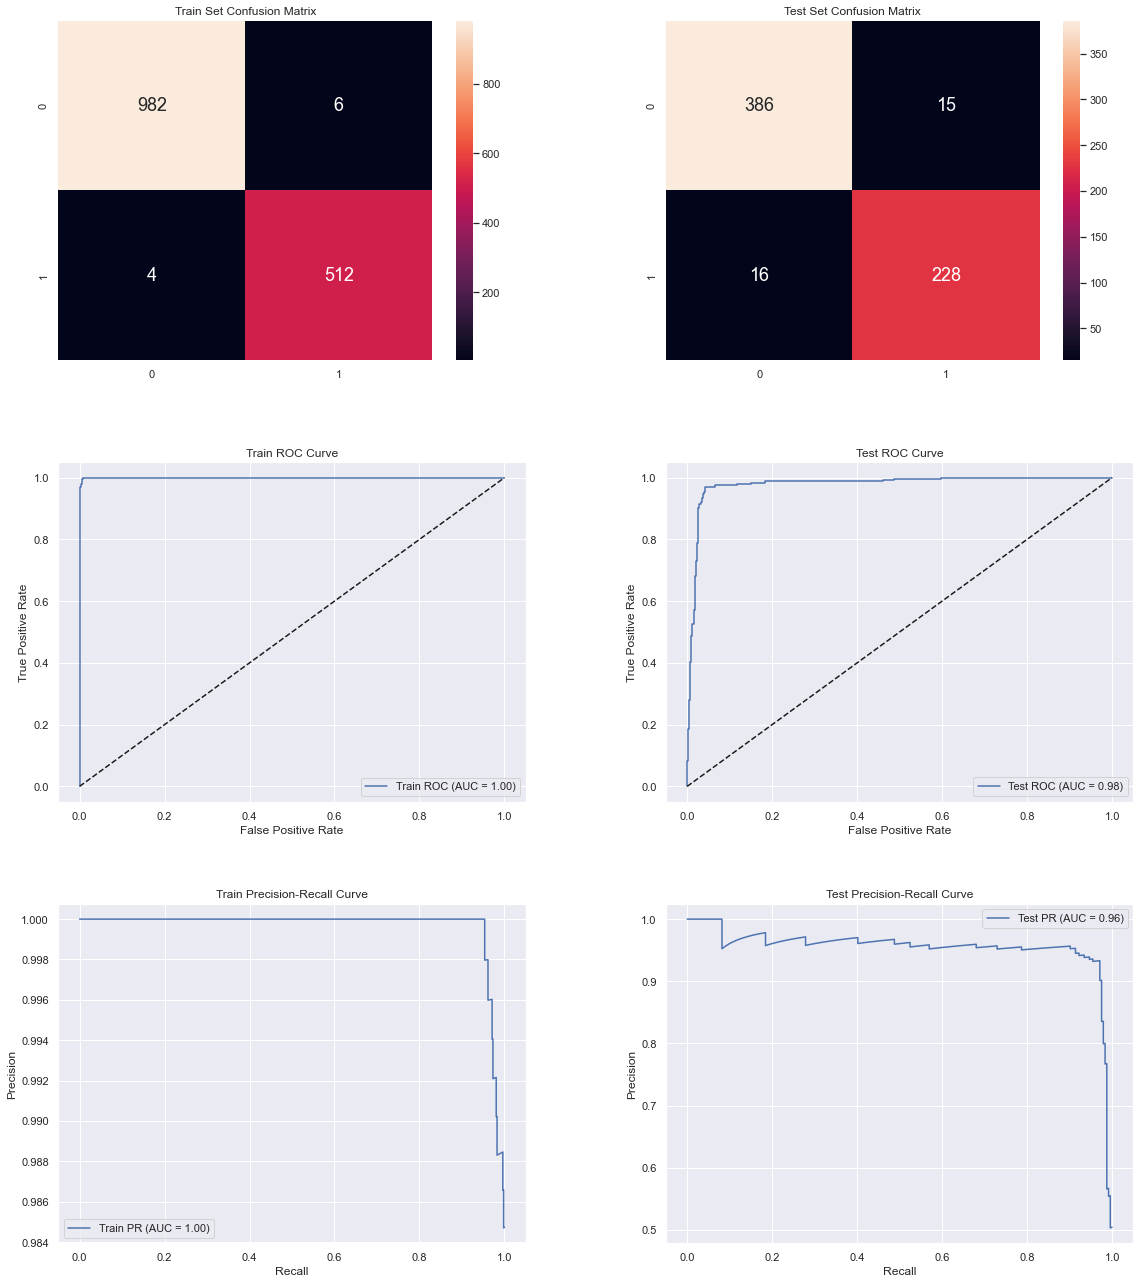

+------------------------------------------------------------------+
|            Model Evaluation Metrics (Gradient Boost)             |
+--------------------------+-------------------+-------------------+
| Goodness of Fit of Model |     Train Dataset |      Test Dataset |
+--------------------------+-------------------+-------------------+
|         Accuracy         | 0.993351063829787 | 0.951937984496124 |
|         AUC ROC          | 0.999813655336911 | 0.978343076734393 |
|          AUC PR          | 0.999641239026162 | 0.955268891933157 |
|         F1 Score         | 0.990328820116054 | 0.936344969199179 |
|        F0.5 Score        | 0.989180834621329 | 0.937500000000000 |
|         F2 Score         | 0.991479473276530 | 0.935192780968007 |
+--------------------------+-------------------+-------------------+


In [70]:
# Create the Gradient Boosting Classifier object
gb = GradientBoostingClassifier(
    learning_rate=0.1261,
    n_estimators=333,
    max_depth=2,
    subsample=0.9840,
    min_samples_split=13,
    min_samples_leaf=20,
    random_state=52
)

# Train the Gradient Boosting model
gb.fit(X_train, y_train)

# Predict
y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

# Calculation of metrics
# Accuracy for Train and Test
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate F0.5 Score for Train and Test
train_f05 = fbeta_score(y_train, y_train_pred, beta=0.5)
test_f05 = fbeta_score(y_test, y_test_pred, beta=0.5)

# Calculate F1 Score for Train and Test
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Calculate F2 Score for Train and Test
train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)

# ROC Curve (with thresholds) for Train and Test
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, gb.predict_proba(X_train)[:, 1])
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, gb.predict_proba(X_test)[:, 1])

# Precision-Recall Curve (with thresholds) for Train and Test
precision_train, recall_train, pr_thresholds_train = precision_recall_curve(y_train, gb.predict_proba(X_train)[:, 1])
precision_test, recall_test, pr_thresholds_test = precision_recall_curve(y_test, gb.predict_proba(X_test)[:, 1])

# Calculate AUC for Train and Test
train_auc = auc(fpr_train, tpr_train)
test_auc = auc(fpr_test, tpr_test)

# Calculate AUC-PR for Train and Test
train_auc_pr = average_precision_score(y_train, gb.predict_proba(X_train)[:, 1])
test_auc_pr = average_precision_score(y_test, gb.predict_proba(X_test)[:, 1])

# Plot curves
# Create a 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(16, 18))

# Plot Confusion Matrix - First row
axs[0, 0].set_title("Train Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 0])
axs[0, 1].set_title("Test Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 1])

# ROC Curve - Second row
axs[1, 0].plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.2f})')
axs[1, 0].plot([0, 1], [0, 1], 'k--')
axs[1, 0].set_xlabel('False Positive Rate')
axs[1, 0].set_ylabel('True Positive Rate')
axs[1, 0].set_title('Train ROC Curve')
axs[1, 0].legend(loc="lower right")

# Plot ROC Curve (Test)
axs[1, 1].plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.2f})')
axs[1, 1].plot([0, 1], [0, 1], 'k--')
axs[1, 1].set_xlabel('False Positive Rate')
axs[1, 1].set_ylabel('True Positive Rate')
axs[1, 1].set_title('Test ROC Curve')
axs[1, 1].legend(loc="lower right")

# PR Curve - Third row
axs[2, 0].plot(recall_train, precision_train, label=f'Train PR (AUC = {train_auc_pr:.2f})')
axs[2, 0].set_xlabel('Recall')
axs[2, 0].set_ylabel('Precision')
axs[2, 0].set_title('Train Precision-Recall Curve')
axs[2, 0].legend()

# Test Precision-Recall Curve
axs[2, 1].plot(recall_test, precision_test, label=f'Test PR (AUC = {test_auc_pr:.2f})')
axs[2, 1].set_xlabel('Recall')
axs[2, 1].set_ylabel('Precision')
axs[2, 1].set_title('Test Precision-Recall Curve')
axs[2, 1].legend()

# Adjust layout for uniform spacing
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3) 
plt.show()

# Create the table
table = PrettyTable()

# Set title and column headers
table.title = "Model Evaluation Metrics (Gradient Boost)"
table.field_names = ["Goodness of Fit of Model", "Train Dataset", "Test Dataset"]

# Add rows with your metrics
table.add_row(["Accuracy", f"{train_accuracy:.15f}", f"{test_accuracy:.15f}"])
table.add_row(["AUC ROC", f"{train_auc:.15f}", f"{test_auc:.15f}"])
table.add_row(["AUC PR", f"{train_auc_pr:.15f}", f"{test_auc_pr:.15f}"])
table.add_row(["F1 Score", f"{train_f1:.15f}", f"{test_f1:.15f}"])
table.add_row(["F0.5 Score", f"{train_f05:.15f}", f"{test_f05:.15f}"])
table.add_row(["F2 Score", f"{train_f2:.15f}", f"{test_f2:.15f}"])

# Customize alignment (right-align numbers)
table.align["Train Dataset"] = "r"
table.align["Test Dataset"] = "r"

# Print the table
print(table)


## 3.3.2.3 Plot F-score against threshold value and indicate on PR Curve plot to determine maximum F2 score and corresponding recall-optimized threshold value

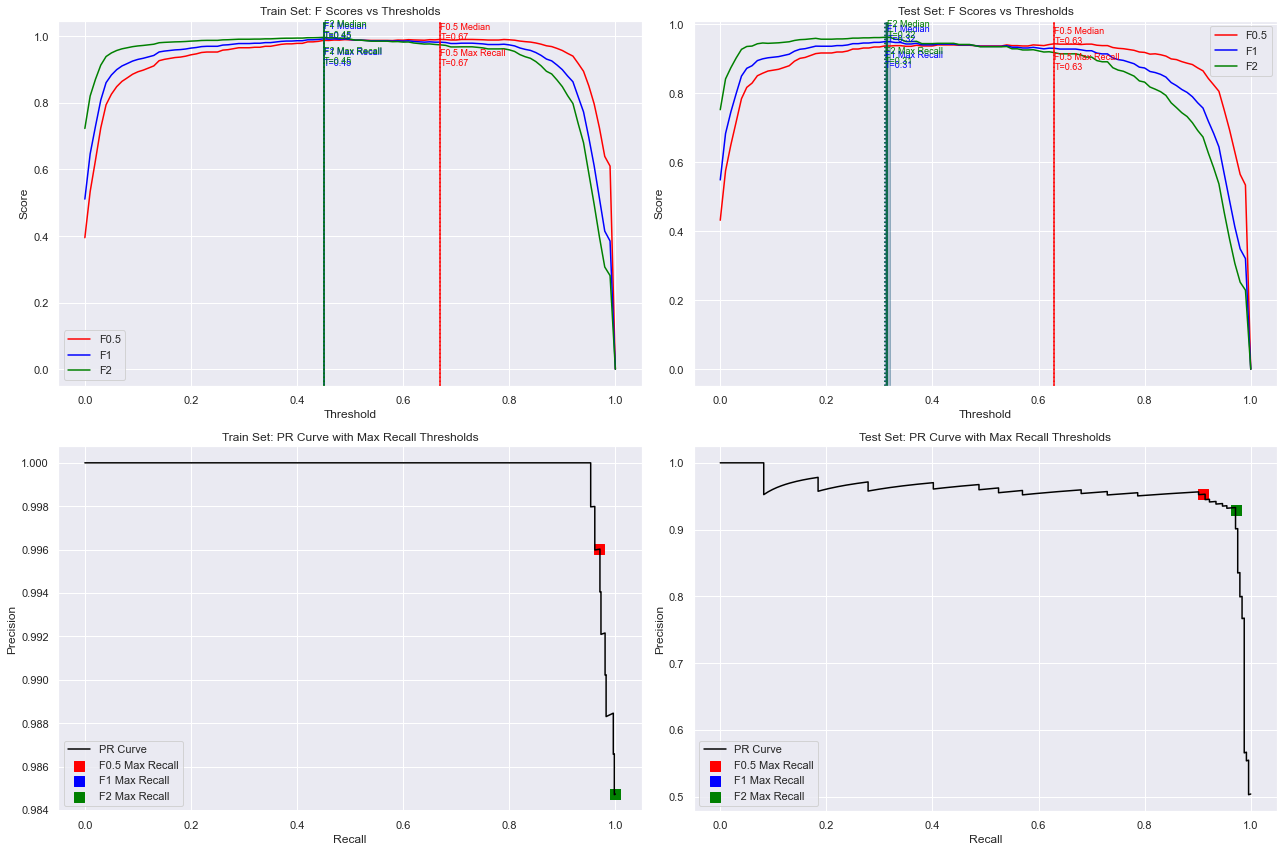

Maximum F2 Scores optimized for recall (Gradient Boost)
Train Set: 0.9969 at threshold 0.45
Test Set: 0.9626 at threshold 0.31


In [71]:
gb = GradientBoostingClassifier(
    learning_rate=0.1261,
    n_estimators=333,
    max_depth=2,
    subsample=0.9840,
    min_samples_split=13,
    min_samples_leaf=20,
    random_state=52
)

gb.fit(X_train, y_train)

# Predict probabilities
y_train_proba = gb.predict_proba(X_train)[:, 1]
y_test_proba = gb.predict_proba(X_test)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0, 1.01, 0.01)

# Calculate F scores
def calculate_metrics(y_true, y_proba, thresholds):
    f1, f2, f05 = [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1.append(f1_score(y_true, y_pred, zero_division=0))
        f2.append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))
        f05.append(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0))
    return f1, f2, f05

# Analyze F-score peak thresholds
def get_threshold_analysis(y_true, y_proba, thresholds, scores):
    max_score = max(scores)
    matching = [t for t, s in zip(thresholds, scores) if s == max_score]

    best_rec = -1
    best_t_rec = None

    for t in matching:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec > best_rec:
            best_rec = rec
            best_t_rec = t

    return {
        "min": min(matching),
        "max": max(matching),
        "median": np.median(matching),
        "best_recall": best_t_rec,
        "max_score": max_score
    }

# PR point from threshold
def find_pr_point(probs, y_true, threshold):
    y_pred = (probs >= threshold).astype(int)
    return recall_score(y_true, y_pred, zero_division=0), precision_score(y_true, y_pred, zero_division=0)

# Calculate scores
train_f1, train_f2, train_f05 = calculate_metrics(y_train, y_train_proba, thresholds)
test_f1, test_f2, test_f05 = calculate_metrics(y_test, y_test_proba, thresholds)

# Get ranges
train_ranges = {
    "F0.5": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f05),
    "F1": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f1),
    "F2": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f2),
}

test_ranges = {
    "F0.5": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f05),
    "F1": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f1),
    "F2": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f2),
}

# PR curves
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
colors = {'F0.5': 'red', 'F1': 'blue', 'F2': 'green'}

# --- Train: F scores vs Threshold ---
axs[0, 0].plot(thresholds, train_f05, label='F0.5', color=colors['F0.5'])
axs[0, 0].plot(thresholds, train_f1, label='F1', color=colors['F1'])
axs[0, 0].plot(thresholds, train_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = train_ranges[label]
    c = colors[label]
    axs[0, 0].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 0].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 0].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 0].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 0].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 0].set_title('Train Set: F Scores vs Thresholds')
axs[0, 0].set_xlabel('Threshold')
axs[0, 0].set_ylabel('Score')
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Test: F scores vs Threshold ---
axs[0, 1].plot(thresholds, test_f05, label='F0.5', color=colors['F0.5'])
axs[0, 1].plot(thresholds, test_f1, label='F1', color=colors['F1'])
axs[0, 1].plot(thresholds, test_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = test_ranges[label]
    c = colors[label]
    axs[0, 1].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 1].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 1].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 1].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 1].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 1].set_title('Test Set: F Scores vs Thresholds')
axs[0, 1].set_xlabel('Threshold')
axs[0, 1].set_ylabel('Score')
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- Train PR Curve ---
axs[1, 0].plot(recall_train, precision_train, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_train_proba, y_train, train_ranges[label]['best_recall'])
    axs[1, 0].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 0].set_title('Train Set: PR Curve with Max Recall Thresholds')
axs[1, 0].set_xlabel('Recall')
axs[1, 0].set_ylabel('Precision')
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- Test PR Curve ---
axs[1, 1].plot(recall_test, precision_test, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_test_proba, y_test, test_ranges[label]['best_recall'])
    axs[1, 1].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 1].set_title('Test Set: PR Curve with Max Recall Thresholds')
axs[1, 1].set_xlabel('Recall')
axs[1, 1].set_ylabel('Precision')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print out max F2 scores
print("Maximum F2 Scores optimized for recall (Gradient Boost)")
print(f"Train Set: {max(train_f2):.4f} at threshold {train_ranges['F2']['best_recall']:.2f}")
print(f"Test Set: {max(test_f2):.4f} at threshold {test_ranges['F2']['best_recall']:.2f}")


## 3.3.3 Random Forest

## 3.3.3.1 Find the optimal hyperparameters using bayesian optimization, optimized based on Area Under Precision-Recall Curve (AUC-PR)

In [62]:
# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameter search space
    n_estimators = trial.suggest_int('n_estimators', 50, 500) 
    max_depth = trial.suggest_int('max_depth', 4, 10) 
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10) 
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)  
    max_features = trial.suggest_categorical('max_features', ['auto', 'sqrt', 'log2']) 

    # Initialize the RandomForest classifier with the selected hyperparameters
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42 
    )

    # Fit the model
    model.fit(X_train, y_train)

    # Predict and calculate the AUC-PR score
    y_pred = model.predict_proba(X_test)[:, 1]
    auc_pr = average_precision_score(y_test, y_pred)

    return auc_pr  # Return AUC-PR score as the objective

# Create the study object
study = optuna.create_study(direction='maximize')

# Optimize the study
study.optimize(objective, n_trials=10)

# Output the best hyperparameters and score after early stopping
print("Best Hyperparameters:")
print(f"Number of Estimators: {study.best_params['n_estimators']}")
print(f"Max Depth: {study.best_params['max_depth']}")
print(f"Min Samples Split: {study.best_params['min_samples_split']}")
print(f"Min Samples Leaf: {study.best_params['min_samples_leaf']}")
print(f"Max Features: {study.best_params['max_features']}")

print(f"\nBest AUC-PR Score: {study.best_value}")


[I 2025-04-14 08:51:48,858] A new study created in memory with name: no-name-17d147a6-9703-4bfd-b181-be3abb760075
[I 2025-04-14 08:51:49,248] Trial 0 finished with value: 0.9430605457999647 and parameters: {'n_estimators': 156, 'max_depth': 9, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.9430605457999647.
[I 2025-04-14 08:51:50,057] Trial 1 finished with value: 0.9440501763911797 and parameters: {'n_estimators': 336, 'max_depth': 9, 'min_samples_split': 6, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9440501763911797.
[I 2025-04-14 08:51:50,664] Trial 2 finished with value: 0.9349277588046278 and parameters: {'n_estimators': 263, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.9440501763911797.
[I 2025-04-14 08:51:51,305] Trial 3 finished with value: 0.9453297262419011 and parameters: {'n_estimators': 266, 'max_depth': 10, 'min

Best Hyperparameters:
Number of Estimators: 330
Max Depth: 9
Min Samples Split: 3
Min Samples Leaf: 5
Max Features: auto

Best AUC-PR Score: 0.9500417255363575


### Comment:
### The number of and range within each hyperparameter are limited due to computational and time constraints. As a future improvement if we have more computing resources, we can consider increasing number of hyperparameters as well as number of trials for Bayesian Optimization to improve the odds of finding a set of parameters that maximizes the metric.

## 3.3.3.2  Use optimized hyperparameters and apply boosted on train set and apply to Test Set. Plot the confusion matrix, ROC and PR Curves as well as print Accuracy, F0.5, F1, F2, AUC-ROC and AUC-PR metrics.

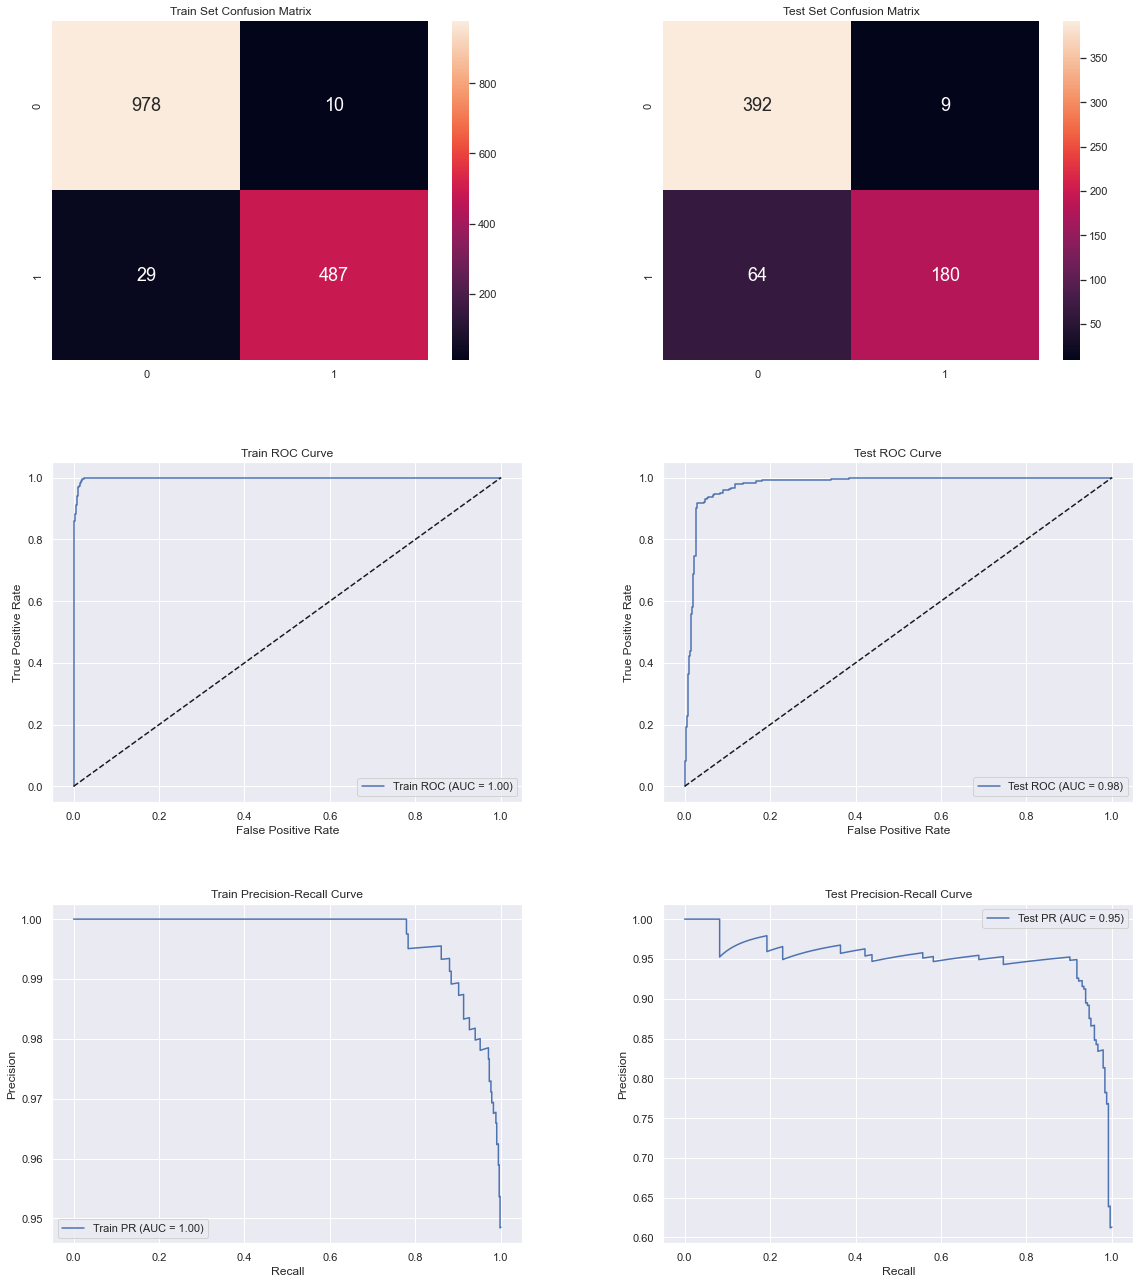

+------------------------------------------------------------------+
|             Model Evaluation Metrics (Random Forest)             |
+--------------------------+-------------------+-------------------+
| Goodness of Fit of Model |     Train Dataset |      Test Dataset |
+--------------------------+-------------------+-------------------+
|         Accuracy         | 0.974069148936170 | 0.886821705426357 |
|         AUC ROC          | 0.998507281172520 | 0.977433465516536 |
|          AUC PR          | 0.997010393273809 | 0.950041725536357 |
|         F1 Score         | 0.961500493583416 | 0.831408775981524 |
|        F0.5 Score        | 0.972444089456869 | 0.900000000000000 |
|         F2 Score         | 0.950800468566966 | 0.772532188841202 |
+--------------------------+-------------------+-------------------+


In [38]:
# Create a Random Forest Classifier object
rf = RandomForestClassifier(
    n_estimators=330,
    max_depth=9,
    min_samples_split=3,
    min_samples_leaf=5,
    max_features='auto',
    random_state=42,
)

# Train the Random Forest Classifier model
rf.fit(X_train, y_train)

# Predict
y_train_pred = rf.predict(X_train).astype(bool)  # Convert to boolean
y_test_pred = rf.predict(X_test).astype(bool)    # Convert to boolean

# Calculation of metrics
# Accuracy for Train and Test
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate F0.5 Score for Train and Test
train_f05 = fbeta_score(y_train, y_train_pred, beta=0.5)
test_f05 = fbeta_score(y_test, y_test_pred, beta=0.5)

# Calculate F1 Score for Train and Test
train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

# Calculate F2 Score for Train and Test
train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)

# ROC Curve (with thresholds) for Train and Test
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, rf.predict_proba(X_train)[:, 1])
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

# Precision-Recall Curve (with thresholds) for Train and Test
precision_train, recall_train, pr_thresholds_train = precision_recall_curve(y_train, rf.predict_proba(X_train)[:, 1])
precision_test, recall_test, pr_thresholds_test = precision_recall_curve(y_test, rf.predict_proba(X_test)[:, 1])

# Calculate AUC for Train and Test
train_auc = auc(fpr_train, tpr_train)
test_auc = auc(fpr_test, tpr_test)

# Calculate AUC-PR for Train and Test
train_auc_pr = average_precision_score(y_train, rf.predict_proba(X_train)[:, 1])
test_auc_pr = average_precision_score(y_test, rf.predict_proba(X_test)[:, 1])

# Plot curves
# Create a 3x2 grid of subplots
fig, axs = plt.subplots(3, 2, figsize=(16, 18))

# Plot Confusion Matrix - First row
axs[0, 0].set_title("Train Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 0])
axs[0, 1].set_title("Test Set Confusion Matrix")
sb.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt=".0f", annot_kws={"size": 18}, ax=axs[0, 1])

# ROC Curve - Second row
axs[1, 0].plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_auc:.2f})')
axs[1, 0].plot([0, 1], [0, 1], 'k--')
axs[1, 0].set_xlabel('False Positive Rate')
axs[1, 0].set_ylabel('True Positive Rate')
axs[1, 0].set_title('Train ROC Curve')
axs[1, 0].legend(loc="lower right")

# Plot ROC Curve (Test)
axs[1, 1].plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_auc:.2f})')
axs[1, 1].plot([0, 1], [0, 1], 'k--')
axs[1, 1].set_xlabel('False Positive Rate')
axs[1, 1].set_ylabel('True Positive Rate')
axs[1, 1].set_title('Test ROC Curve')
axs[1, 1].legend(loc="lower right")

# PR Curve - Third row
axs[2, 0].plot(recall_train, precision_train, label=f'Train PR (AUC = {train_auc_pr:.2f})')
axs[2, 0].set_xlabel('Recall')
axs[2, 0].set_ylabel('Precision')
axs[2, 0].set_title('Train Precision-Recall Curve')
axs[2, 0].legend()

# Test Precision-Recall Curve
axs[2, 1].plot(recall_test, precision_test, label=f'Test PR (AUC = {test_auc_pr:.2f})')
axs[2, 1].set_xlabel('Recall')
axs[2, 1].set_ylabel('Precision')
axs[2, 1].set_title('Test Precision-Recall Curve')
axs[2, 1].legend()

# Adjust layout for uniform spacing
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, wspace=0.3) 
plt.show()

# Create the table
table = PrettyTable()

# Set title and column headers
table.title = "Model Evaluation Metrics (Random Forest)"
table.field_names = ["Goodness of Fit of Model", "Train Dataset", "Test Dataset"]

# Add rows with your metrics
table.add_row(["Accuracy", f"{train_accuracy:.15f}", f"{test_accuracy:.15f}"])
table.add_row(["AUC ROC", f"{train_auc:.15f}", f"{test_auc:.15f}"])
table.add_row(["AUC PR", f"{train_auc_pr:.15f}", f"{test_auc_pr:.15f}"])
table.add_row(["F1 Score", f"{train_f1:.15f}", f"{test_f1:.15f}"])
table.add_row(["F0.5 Score", f"{train_f05:.15f}", f"{test_f05:.15f}"])
table.add_row(["F2 Score", f"{train_f2:.15f}", f"{test_f2:.15f}"])

# Customize alignment (right-align numbers)
table.align["Train Dataset"] = "r"
table.align["Test Dataset"] = "r"

# Print the table
print(table)

## 3.3.3.3 Plot F-score against threshold value and indicate on PR Curve plot to determine maximum F2 score and corresponding recall-optimized threshold value

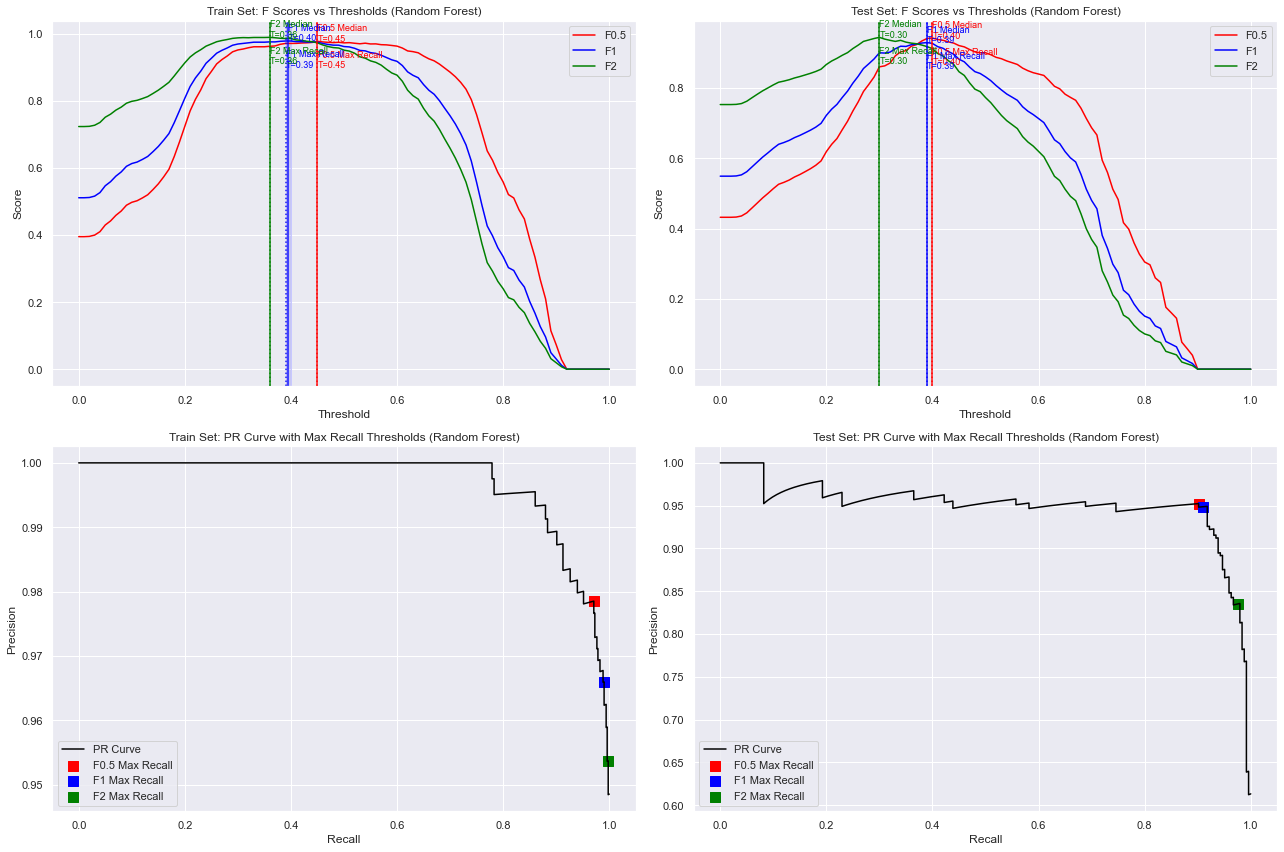

Maximum F2 Scores optimized for recall (Random Forest)
Train Set: 0.9889 at threshold 0.36
Test Set: 0.9437 at threshold 0.30


In [64]:
# Initialize and train Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=330,
    max_depth=9,
    min_samples_split=3,
    min_samples_leaf=5,
    max_features='auto',
    random_state=42,
)

# Train the model
rf.fit(X_train, y_train)

# Predict probabilities
y_train_proba = rf.predict_proba(X_train)[:, 1]
y_test_proba = rf.predict_proba(X_test)[:, 1]

# Thresholds to evaluate
thresholds = np.arange(0, 1.01, 0.01)

# Calculate F scores
def calculate_metrics(y_true, y_proba, thresholds):
    f1, f2, f05 = [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1.append(f1_score(y_true, y_pred, zero_division=0))
        f2.append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))
        f05.append(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0))
    return f1, f2, f05

# Analyze F-score peak thresholds
def get_threshold_analysis(y_true, y_proba, thresholds, scores):
    max_score = max(scores)
    matching = [t for t, s in zip(thresholds, scores) if s == max_score]

    best_rec = -1
    best_t_rec = None

    for t in matching:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec > best_rec:
            best_rec = rec
            best_t_rec = t

    return {
        "min": min(matching),
        "max": max(matching),
        "median": np.median(matching),
        "best_recall": best_t_rec,
        "max_score": max_score
    }

# PR point from threshold
def find_pr_point(probs, y_true, threshold):
    y_pred = (probs >= threshold).astype(int)
    return recall_score(y_true, y_pred, zero_division=0), precision_score(y_true, y_pred, zero_division=0)

# Calculate scores
train_f1, train_f2, train_f05 = calculate_metrics(y_train, y_train_proba, thresholds)
test_f1, test_f2, test_f05 = calculate_metrics(y_test, y_test_proba, thresholds)

# Get ranges
train_ranges = {
    "F0.5": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f05),
    "F1": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f1),
    "F2": get_threshold_analysis(y_train, y_train_proba, thresholds, train_f2),
}

test_ranges = {
    "F0.5": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f05),
    "F1": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f1),
    "F2": get_threshold_analysis(y_test, y_test_proba, thresholds, test_f2),
}

# PR curves
precision_train, recall_train, _ = precision_recall_curve(y_train, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_proba)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
colors = {'F0.5': 'red', 'F1': 'blue', 'F2': 'green'}

# --- Train: F scores vs Threshold ---
axs[0, 0].plot(thresholds, train_f05, label='F0.5', color=colors['F0.5'])
axs[0, 0].plot(thresholds, train_f1, label='F1', color=colors['F1'])
axs[0, 0].plot(thresholds, train_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = train_ranges[label]
    c = colors[label]
    axs[0, 0].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 0].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 0].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 0].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 0].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 0].set_title('Train Set: F Scores vs Thresholds (Random Forest)')
axs[0, 0].set_xlabel('Threshold')
axs[0, 0].set_ylabel('Score')
axs[0, 0].legend()
axs[0, 0].grid(True)

# --- Test: F scores vs Threshold ---
axs[0, 1].plot(thresholds, test_f05, label='F0.5', color=colors['F0.5'])
axs[0, 1].plot(thresholds, test_f1, label='F1', color=colors['F1'])
axs[0, 1].plot(thresholds, test_f2, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = test_ranges[label]
    c = colors[label]
    axs[0, 1].axvspan(band['min'], band['max'], color=c, alpha=0.15)

    axs[0, 1].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 1].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)

    axs[0, 1].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 1].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 1].set_title('Test Set: F Scores vs Thresholds (Random Forest)')
axs[0, 1].set_xlabel('Threshold')
axs[0, 1].set_ylabel('Score')
axs[0, 1].legend()
axs[0, 1].grid(True)

# --- Train PR Curve --- 
axs[1, 0].plot(recall_train, precision_train, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_train_proba, y_train, train_ranges[label]['best_recall'])
    axs[1, 0].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 0].set_title('Train Set: PR Curve with Max Recall Thresholds (Random Forest)')
axs[1, 0].set_xlabel('Recall')
axs[1, 0].set_ylabel('Precision')
axs[1, 0].legend()
axs[1, 0].grid(True)

# --- Test PR Curve --- 
axs[1, 1].plot(recall_test, precision_test, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_test_proba, y_test, test_ranges[label]['best_recall'])
    axs[1, 1].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 1].set_title('Test Set: PR Curve with Max Recall Thresholds (Random Forest)')
axs[1, 1].set_xlabel('Recall')
axs[1, 1].set_ylabel('Precision')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print out max F2 scores
print("Maximum F2 Scores optimized for recall (Random Forest)")
print(f"Train Set: {max(train_f2):.4f} at threshold {train_ranges['F2']['best_recall']:.2f}")
print(f"Test Set: {max(test_f2):.4f} at threshold {test_ranges['F2']['best_recall']:.2f}")

## 3.4 Other Novel Classification Model (New things that we have learnt on our own)
## 3.4.1 Neural Network
## 3.4.1.1 Find the optimal hyperparameters using bayesian optimization, optimized based on Area Under Precision-Recall Curve (AUC-PR)

In [66]:
def objective(trial):
    # Define the hyperparameter search space
    n_layers = trial.suggest_int('n_layers', 1, 10)
    units = trial.suggest_int('units', 32, 512, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.0, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh', 'selu'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    
    # Convert data to numpy arrays with proper dtype
    X_train_np = X_train.to_numpy().astype(np.float32)
    y_train_np = y_train.to_numpy().astype(np.float32)
    X_test_np = X_test.to_numpy().astype(np.float32)
    y_test_np = y_test.to_numpy().astype(np.float32)
    
    # Build the model
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train_np.shape[1],)))
    
    # Add hidden layers
    for _ in range(n_layers):
        model.add(layers.Dense(units=units, activation=activation))
        model.add(layers.Dropout(dropout_rate))
    
    # Add output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    # Early stopping callback
    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
    
    # Train the model
    history = model.fit(
        X_train_np, y_train_np,
        validation_split=0.2,
        batch_size=batch_size,
        epochs=100,
        callbacks=[early_stopping],
        verbose=0
    )
    
    # Predict and calculate the AUC-PR score
    y_pred = model.predict(X_test_np, verbose=0)
    auc_pr = average_precision_score(y_test_np, y_pred)
    
    return auc_pr

# Create the study object
study = optuna.create_study(direction='maximize')

# Optimize the study
study.optimize(objective, n_trials=10)

# Output the best hyperparameters and score
print("Best Hyperparameters:")
print(f"Number of Layers: {study.best_params['n_layers']}")
print(f"Units per Layer: {study.best_params['units']}")
print(f"Dropout Rate: {study.best_params['dropout_rate']}")
print(f"Learning Rate: {study.best_params['learning_rate']}")
print(f"Activation Function: {study.best_params['activation']}")
print(f"Batch Size: {study.best_params['batch_size']}")

print(f"\nBest AUC-PR Score: {study.best_value}")

[I 2025-04-14 08:53:57,095] A new study created in memory with name: no-name-20f58c4e-1839-4b40-b196-c5620cf2ac32
[I 2025-04-14 08:53:59,222] Trial 0 finished with value: 0.42569327427208 and parameters: {'n_layers': 5, 'units': 290, 'dropout_rate': 0.25583572007283933, 'learning_rate': 0.003597365225750452, 'activation': 'selu', 'batch_size': 128}. Best is trial 0 with value: 0.42569327427208.
[I 2025-04-14 08:54:00,280] Trial 1 finished with value: 0.40220591702477304 and parameters: {'n_layers': 6, 'units': 103, 'dropout_rate': 0.1200409366642512, 'learning_rate': 1.2569968509087336e-05, 'activation': 'tanh', 'batch_size': 64}. Best is trial 0 with value: 0.42569327427208.
[I 2025-04-14 08:54:01,418] Trial 2 finished with value: 0.3712627931893756 and parameters: {'n_layers': 6, 'units': 91, 'dropout_rate': 0.4772764358700044, 'learning_rate': 5.3496566282129496e-05, 'activation': 'selu', 'batch_size': 64}. Best is trial 0 with value: 0.42569327427208.
[I 2025-04-14 08:54:03,765] Tr

Best Hyperparameters:
Number of Layers: 5
Units per Layer: 290
Dropout Rate: 0.25583572007283933
Learning Rate: 0.003597365225750452
Activation Function: selu
Batch Size: 128

Best AUC-PR Score: 0.42569327427208


## 3.4.1.2  Use optimized hyperparameter and apply boosted on train set and apply to Test Set. Plot the confusion matrix, ROC and PR Curves as well as print Accuracy, F0.5, F1, F2, AUC-ROC and AUC-PR metrics. Also plot the AUC PR against Epoch and Loss against Epoch Curves

Epoch 1/200
12/12 [==============================] - 1s 27ms/step - loss: 1.2362 - accuracy: 0.4947 - auc: 0.4679 - val_loss: 1.4270 - val_accuracy: 0.3829 - val_auc: 0.5109
Epoch 2/200
12/12 [==============================] - 0s 7ms/step - loss: 0.7259 - accuracy: 0.5984 - auc: 0.4974 - val_loss: 4.9836 - val_accuracy: 0.3798 - val_auc: 0.5110
Epoch 3/200
12/12 [==============================] - 0s 7ms/step - loss: 0.7256 - accuracy: 0.5984 - auc: 0.4893 - val_loss: 3.8847 - val_accuracy: 0.4155 - val_auc: 0.4980
Epoch 4/200
12/12 [==============================] - 0s 7ms/step - loss: 0.6776 - accuracy: 0.6350 - auc: 0.5399 - val_loss: 2.0435 - val_accuracy: 0.4372 - val_auc: 0.5071
Epoch 5/200
12/12 [==============================] - 0s 7ms/step - loss: 0.6762 - accuracy: 0.6170 - auc: 0.5253 - val_loss: 1.9951 - val_accuracy: 0.4434 - val_auc: 0.5046
Epoch 6/200
12/12 [==============================] - 0s 7ms/step - loss: 0.6985 - accuracy: 0.6164 - auc: 0.4990 - val_loss: 0.9388 - 

12/12 [==============================] - 0s 7ms/step - loss: 0.3322 - accuracy: 0.8517 - auc: 0.9234 - val_loss: 0.4198 - val_accuracy: 0.8171 - val_auc: 0.8844
Epoch 96/200
12/12 [==============================] - 0s 7ms/step - loss: 0.3217 - accuracy: 0.8597 - auc: 0.9283 - val_loss: 0.4229 - val_accuracy: 0.8078 - val_auc: 0.8822
Epoch 97/200
12/12 [==============================] - 0s 7ms/step - loss: 0.3213 - accuracy: 0.8511 - auc: 0.9284 - val_loss: 0.4200 - val_accuracy: 0.8186 - val_auc: 0.8854
Epoch 98/200
12/12 [==============================] - 0s 7ms/step - loss: 0.3198 - accuracy: 0.8544 - auc: 0.9300 - val_loss: 0.4195 - val_accuracy: 0.8186 - val_auc: 0.8852
Epoch 99/200
12/12 [==============================] - 0s 7ms/step - loss: 0.3141 - accuracy: 0.8604 - auc: 0.9312 - val_loss: 0.4193 - val_accuracy: 0.8186 - val_auc: 0.8866
Epoch 100/200
12/12 [==============================] - 0s 7ms/step - loss: 0.3268 - accuracy: 0.8537 - auc: 0.9261 - val_loss: 0.4198 - val_acc

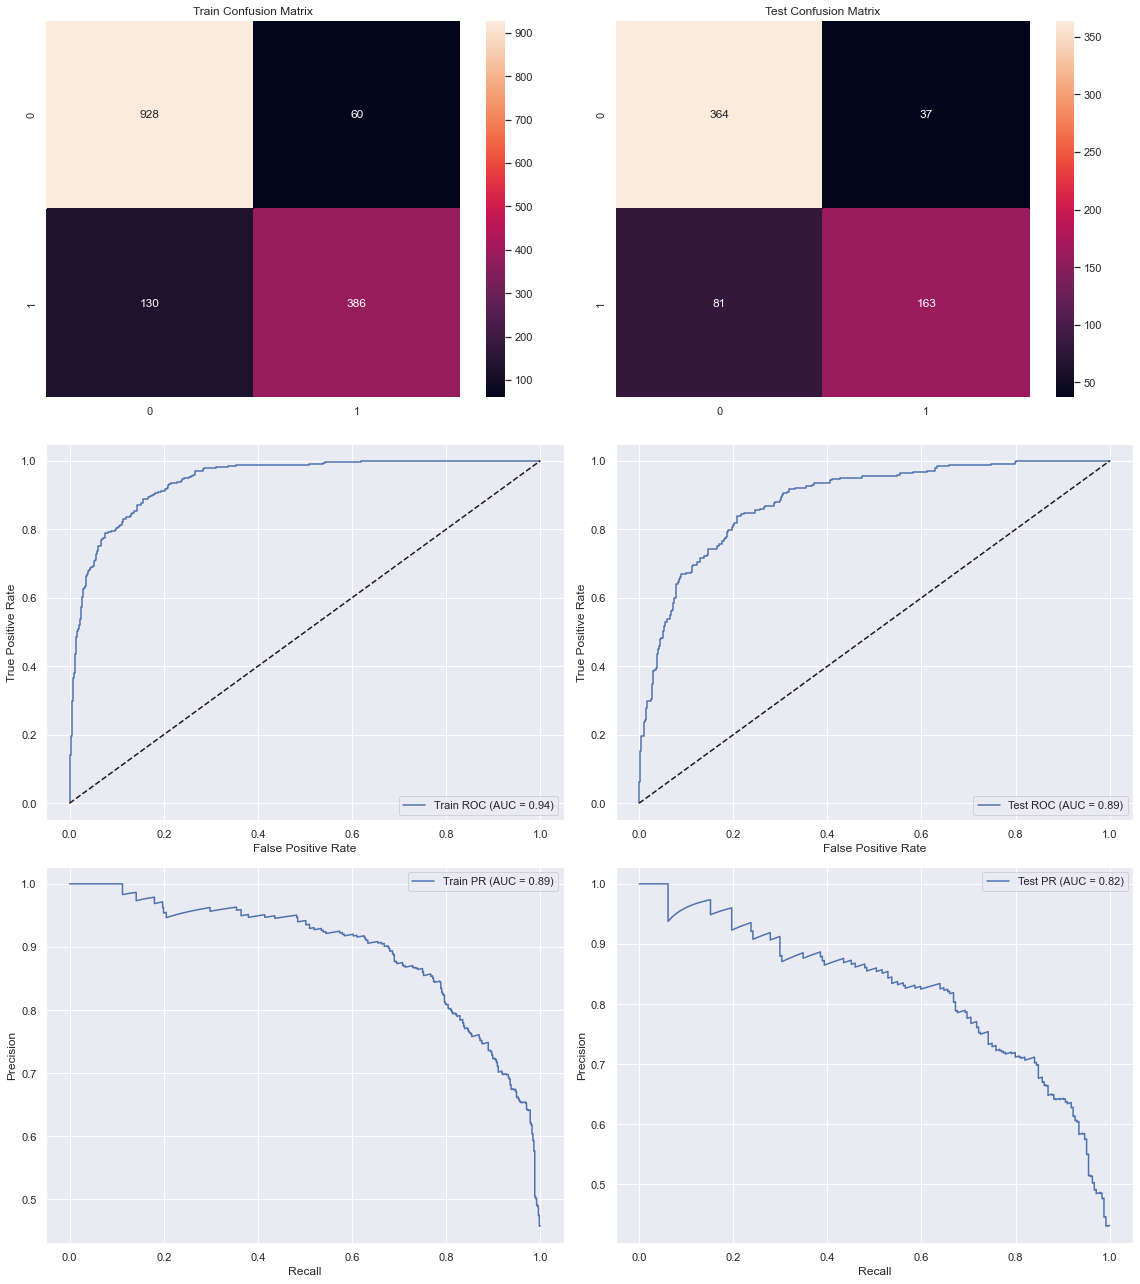

+----------------------------------------------------+
|      Model Evaluation Metrics (Neural Network)     |
+------------+-------------------+-------------------+
|   Metric   |       Train       |        Test       |
+------------+-------------------+-------------------+
|  Accuracy  | 0.873670212765957 | 0.817054263565892 |
|  AUC-ROC   | 0.943143301007438 | 0.885153918482482 |
|   AUC-PR   | 0.894623118192099 | 0.823457511350256 |
|  F1 Score  | 0.802494802494802 | 0.734234234234234 |
| F0.5 Score | 0.839130434782609 | 0.780651340996168 |
|  F2 Score  | 0.768924302788844 | 0.693027210884354 |
+------------+-------------------+-------------------+


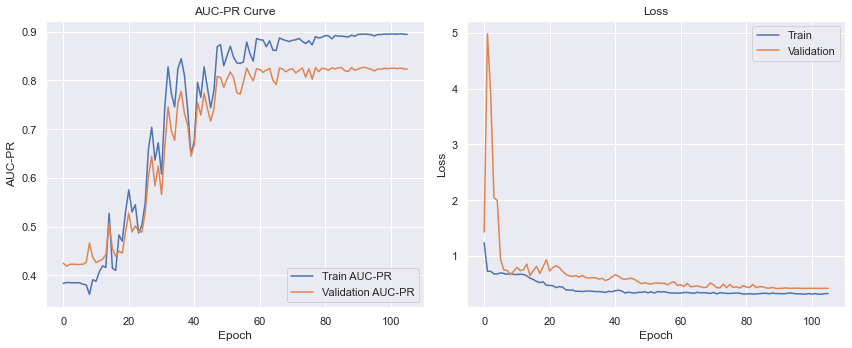

In [49]:
# Convert to float32 arrays with _FP suffix
X_train_FP = np.asarray(X_train).astype('float32')
y_train_FP = np.asarray(y_train).astype('float32')
X_test_FP = np.asarray(X_test).astype('float32')
y_test_FP = np.asarray(y_test).astype('float32')

# Define the optimized neural network with your hyperparameters directly
def create_optimized_nn(input_dim):
    model = Sequential()
    
    # Input layer
    model.add(Dense(290, input_dim=input_dim, activation='selu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.2558))
    
    # Hidden layers
    for _ in range(3):
        model.add(Dense(290, activation='selu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.2558))
    
    # Output layer
    model.add(Dense(1, activation='sigmoid'))
    
    optimizer = Adam(learning_rate=0.0036)
    model.compile(loss='binary_crossentropy', 
                 optimizer=optimizer, 
                 metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

# Create model
model = create_optimized_nn(X_train_FP.shape[1])

# Custom callback to calculate AUC-PR after each epoch
class AUC_PR_Callback(tf.keras.callbacks.Callback):
    def __init__(self, validation_data):
        super(AUC_PR_Callback, self).__init__()
        self.validation_data = validation_data
        self.train_auc_pr = []
        self.val_auc_pr = []

    def on_epoch_end(self, epoch, logs=None):
        # Get the validation data
        X_val, y_val = self.validation_data

        # Compute PR AUC for training and validation data
        y_train_proba = self.model.predict(X_train_FP) 
        y_val_proba = self.model.predict(X_val)  

        train_auc_pr = average_precision_score(y_train_FP, y_train_proba.flatten())
        val_auc_pr = average_precision_score(y_val, y_val_proba.flatten())

        self.train_auc_pr.append(train_auc_pr)
        self.val_auc_pr.append(val_auc_pr)

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True),
    AUC_PR_Callback(validation_data=(X_test_FP, y_test_FP))  # Pass validation data here
]

# Train the model
history = model.fit(X_train_FP, y_train_FP,
                   validation_data=(X_test_FP, y_test_FP),
                   epochs=200,
                   batch_size=128,
                   callbacks=callbacks,
                   verbose=1)

# Predict probabilities
y_train_proba = model.predict(X_train_FP).flatten()
y_test_proba = model.predict(X_test_FP).flatten()

# Convert to boolean predictions
y_train_pred = (y_train_proba > 0.5).astype(bool)
y_test_pred = (y_test_proba > 0.5).astype(bool)

# Evaluation metrics
def calculate_metrics(y_true, y_pred, y_proba):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'f05': fbeta_score(y_true, y_pred, beta=0.5),
        'f1': f1_score(y_true, y_pred),
        'f2': fbeta_score(y_true, y_pred, beta=2),
        'auc': auc(*roc_curve(y_true, y_proba)[:2]),
        'auc_pr': average_precision_score(y_true, y_proba),
        'cm': confusion_matrix(y_true, y_pred)
    }

train_metrics = calculate_metrics(y_train_FP, y_train_pred, y_train_proba)
test_metrics = calculate_metrics(y_test_FP, y_test_pred, y_test_proba)

# Plotting
fig, axs = plt.subplots(3, 2, figsize=(16, 18))

# Confusion matrices
sb.heatmap(train_metrics['cm'], annot=True, fmt=".0f", ax=axs[0,0])
axs[0,0].set_title("Train Confusion Matrix")
sb.heatmap(test_metrics['cm'], annot=True, fmt=".0f", ax=axs[0,1])
axs[0,1].set_title("Test Confusion Matrix")

# ROC curves
fpr_train, tpr_train, _ = roc_curve(y_train_FP, y_train_proba)
fpr_test, tpr_test, _ = roc_curve(y_test_FP, y_test_proba)
axs[1,0].plot(fpr_train, tpr_train, label=f'Train ROC (AUC = {train_metrics["auc"]:.2f})')
axs[1,1].plot(fpr_test, tpr_test, label=f'Test ROC (AUC = {test_metrics["auc"]:.2f})')
for ax in axs[1,:]:
    ax.plot([0,1],[0,1],'k--')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')

# PR curves
precision_train, recall_train, _ = precision_recall_curve(y_train_FP, y_train_proba)
precision_test, recall_test, _ = precision_recall_curve(y_test_FP, y_test_proba)
axs[2,0].plot(recall_train, precision_train, label=f'Train PR (AUC = {train_metrics["auc_pr"]:.2f})')
axs[2,1].plot(recall_test, precision_test, label=f'Test PR (AUC = {test_metrics["auc_pr"]:.2f})')
for ax in axs[2,:]:
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.legend()

plt.tight_layout()
plt.show()

# Metrics table
metrics_table = PrettyTable()
metrics_table.title = "Model Evaluation Metrics (Neural Network)"
metrics_table.field_names = ["Metric", "Train", "Test"]
metrics_table.add_rows([
    ["Accuracy", f"{train_metrics['accuracy']:.15f}", f"{test_metrics['accuracy']:.15f}"],
    ["AUC-ROC", f"{train_metrics['auc']:.15f}", f"{test_metrics['auc']:.15f}"],
    ["AUC-PR", f"{train_metrics['auc_pr']:.15f}", f"{test_metrics['auc_pr']:.15f}"],
    ["F1 Score", f"{train_metrics['f1']:.15f}", f"{test_metrics['f1']:.15f}"],
    ["F0.5 Score", f"{train_metrics['f05']:.15f}", f"{test_metrics['f05']:.15f}"],
    ["F2 Score", f"{train_metrics['f2']:.15f}", f"{test_metrics['f2']:.15f}"]
])
print(metrics_table)

# Training history plot for AUC-PR
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(callbacks[3].train_auc_pr, label='Train AUC-PR')
plt.plot(callbacks[3].val_auc_pr, label='Validation AUC-PR')
plt.title('AUC-PR Curve')
plt.ylabel('AUC-PR')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

### Comment:
### AUC PR Plot (Left): The train set AUC RP increases steadily and reaches around 0.90 by the end of 40 epochs, which shows model is learning well. However the validation (test) set AUC RP starts at a lower value and fluctuates within the first 40 epochs, which suggests early instability or overfitting risks. However, it eventually stabilizes, though it hits a plateau and stabilizes at around 0.83, slightly lower than the training AUC RP. This indicates the model generalizes quite well to unseen data, though there's still room for improvement.

### Loss Plot (Right): The train set loss begins at a low value for early epoches and continues to trend downwards, showing the model has good fit to training data. However the validation (test) set loss starts off very high and before decreasing rapidly. It continues to fluctuate and tapers off above the training loss. This shows that the model is not overfitting much on unseen data and is generalizing well but also still with room for improvements.

## 3.4.1.3 Plot F-score against threshold value and indicate on PR Curve plot to determine maximum F2 score and corresponding recall-optimized threshold value


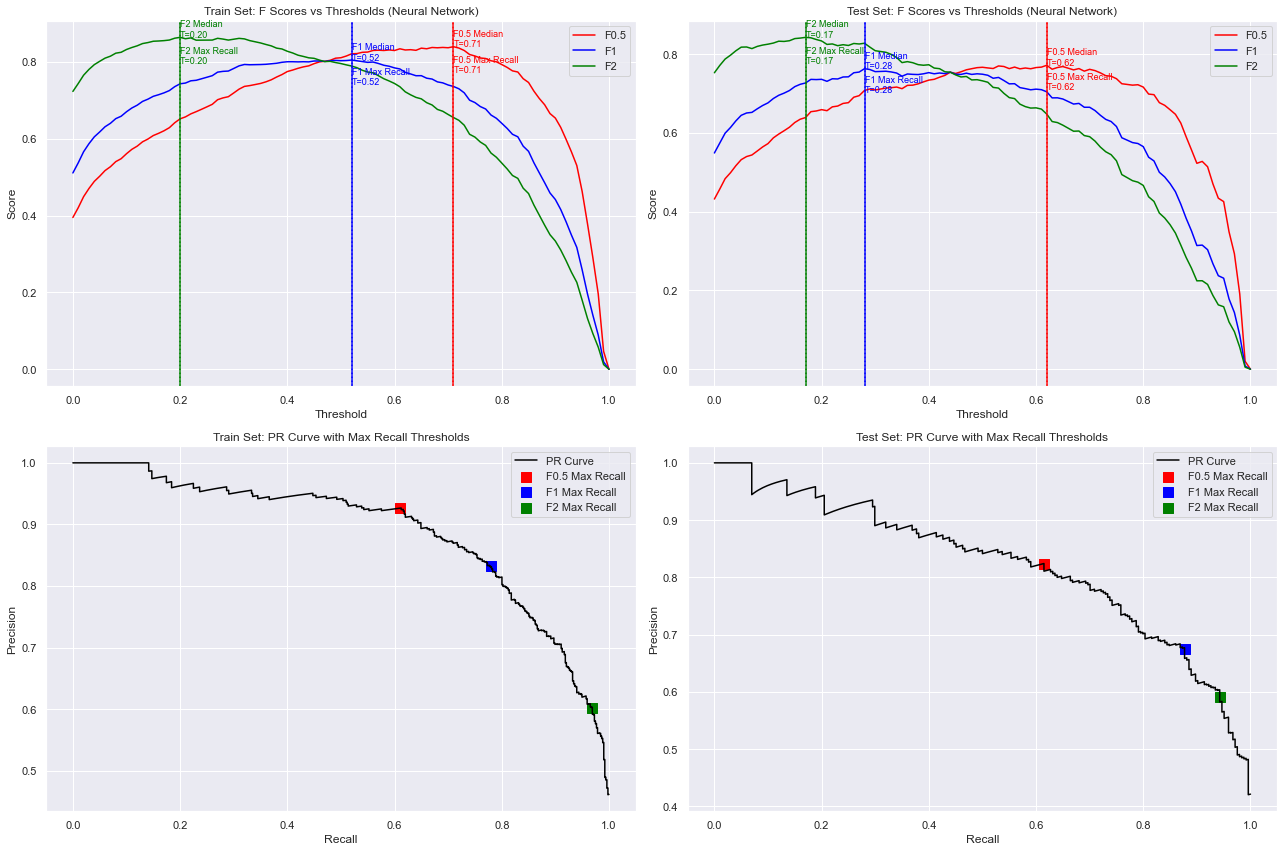

Maximum F2 Scores optimized for recall (Neural Network):
Train Set: Max F2 = 0.8639 at threshold 0.20
Test Set: Max F2 = 0.8425 at threshold 0.17


In [65]:
# Predict probabilities from neural network
y_train_proba_nn = model.predict(X_train_FP).flatten()
y_test_proba_nn = model.predict(X_test_FP).flatten()

# Define the metrics calculation function
def calculate_metrics(y_true, y_proba, thresholds):
    f1, f2, f05 = [], [], []
    for thresh in thresholds:
        y_pred = (y_proba >= thresh).astype(int)
        f1.append(f1_score(y_true, y_pred, zero_division=0))
        f2.append(fbeta_score(y_true, y_pred, beta=2, zero_division=0))
        f05.append(fbeta_score(y_true, y_pred, beta=0.5, zero_division=0))
    return f1, f2, f05

# Threshold analysis function
def get_threshold_analysis(y_true, y_proba, thresholds, scores):
    max_score = max(scores)
    matching = [t for t, s in zip(thresholds, scores) if s == max_score]

    best_rec = -1
    best_t_rec = None

    for t in matching:
        y_pred = (y_proba >= t).astype(int)
        rec = recall_score(y_true, y_pred, zero_division=0)
        if rec > best_rec:
            best_rec = rec
            best_t_rec = t

    return {
        "min": min(matching),
        "max": max(matching),
        "median": np.median(matching),
        "best_recall": best_t_rec,
        "max_score": max_score
    }

# PR point from threshold
def find_pr_point(probs, y_true, threshold):
    y_pred = (probs >= threshold).astype(int)
    return recall_score(y_true, y_pred, zero_division=0), precision_score(y_true, y_pred, zero_division=0)

# Thresholds to evaluate
thresholds = np.arange(0, 1.01, 0.01)

# Calculate scores
train_f1_nn, train_f2_nn, train_f05_nn = calculate_metrics(y_train_FP, y_train_proba_nn, thresholds)
test_f1_nn, test_f2_nn, test_f05_nn = calculate_metrics(y_test_FP, y_test_proba_nn, thresholds)

# Get optimal threshold ranges
train_ranges_nn = {
    "F0.5": get_threshold_analysis(y_train_FP, y_train_proba_nn, thresholds, train_f05_nn),
    "F1": get_threshold_analysis(y_train_FP, y_train_proba_nn, thresholds, train_f1_nn),
    "F2": get_threshold_analysis(y_train_FP, y_train_proba_nn, thresholds, train_f2_nn),
}

test_ranges_nn = {
    "F0.5": get_threshold_analysis(y_test_FP, y_test_proba_nn, thresholds, test_f05_nn),
    "F1": get_threshold_analysis(y_test_FP, y_test_proba_nn, thresholds, test_f1_nn),
    "F2": get_threshold_analysis(y_test_FP, y_test_proba_nn, thresholds, test_f2_nn),
}

# PR curves
precision_train_nn, recall_train_nn, _ = precision_recall_curve(y_train_FP, y_train_proba_nn)
precision_test_nn, recall_test_nn, _ = precision_recall_curve(y_test_FP, y_test_proba_nn)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
colors = {'F0.5': 'red', 'F1': 'blue', 'F2': 'green'}

# Train: F scores vs Threshold
axs[0, 0].plot(thresholds, train_f05_nn, label='F0.5', color=colors['F0.5'])
axs[0, 0].plot(thresholds, train_f1_nn, label='F1', color=colors['F1'])
axs[0, 0].plot(thresholds, train_f2_nn, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = train_ranges_nn[label]
    c = colors[label]
    axs[0, 0].axvspan(band['min'], band['max'], color=c, alpha=0.15)
    axs[0, 0].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 0].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)
    axs[0, 0].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 0].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 0].set_title('Train Set: F Scores vs Thresholds (Neural Network)')
axs[0, 0].set_xlabel('Threshold')
axs[0, 0].set_ylabel('Score')
axs[0, 0].legend()
axs[0, 0].grid(True)

# Test: F scores vs Threshold
axs[0, 1].plot(thresholds, test_f05_nn, label='F0.5', color=colors['F0.5'])
axs[0, 1].plot(thresholds, test_f1_nn, label='F1', color=colors['F1'])
axs[0, 1].plot(thresholds, test_f2_nn, label='F2', color=colors['F2'])

for label in ['F0.5', 'F1', 'F2']:
    band = test_ranges_nn[label]
    c = colors[label]
    axs[0, 1].axvspan(band['min'], band['max'], color=c, alpha=0.15)
    axs[0, 1].axvline(band['median'], color=c, linestyle='-', alpha=0.9)
    axs[0, 1].text(band['median'], band['max_score'], f'{label} Median\nT={band["median"]:.2f}', color=c, fontsize=9)
    axs[0, 1].axvline(band['best_recall'], color=c, linestyle=':', alpha=0.9)
    axs[0, 1].text(band['best_recall'], band['max_score']*0.92, f'{label} Max Recall\nT={band["best_recall"]:.2f}', color=c, fontsize=9)

axs[0, 1].set_title('Test Set: F Scores vs Thresholds (Neural Network)')
axs[0, 1].set_xlabel('Threshold')
axs[0, 1].set_ylabel('Score')
axs[0, 1].legend()
axs[0, 1].grid(True)

# Train PR Curve
axs[1, 0].plot(recall_train_nn, precision_train_nn, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_train_proba_nn, y_train_FP, train_ranges_nn[label]['best_recall'])
    axs[1, 0].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 0].set_title('Train Set: PR Curve with Max Recall Thresholds')
axs[1, 0].set_xlabel('Recall')
axs[1, 0].set_ylabel('Precision')
axs[1, 0].legend()
axs[1, 0].grid(True)

# Test PR Curve
axs[1, 1].plot(recall_test_nn, precision_test_nn, label='PR Curve', color='black')
for label in ['F0.5', 'F1', 'F2']:
    c = colors[label]
    r, p = find_pr_point(y_test_proba_nn, y_test_FP, test_ranges_nn[label]['best_recall'])
    axs[1, 1].scatter(r, p, s=100, c=c, marker='s', label=f'{label} Max Recall')

axs[1, 1].set_title('Test Set: PR Curve with Max Recall Thresholds')
axs[1, 1].set_xlabel('Recall')
axs[1, 1].set_ylabel('Precision')
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()

# Print optimal F2 scores
print("Maximum F2 Scores optimized for recall (Neural Network):")
print(f"Train Set: Max F2 = {max(train_f2_nn):.4f} at threshold {train_ranges_nn['F2']['best_recall']:.2f}")
print(f"Test Set: Max F2 = {max(test_f2_nn):.4f} at threshold {test_ranges_nn['F2']['best_recall']:.2f}")

# 4. Conclusion

### Results analysis

| Model           | Train F2 | Threshold | Test F2 | Threshold | Overfitting (gap)    |
|----------------|----------|-----------|---------|-----------|------------------|
| Decision Tree  | 0.9666   | 0.02      | 0.9220  | 0.34      | High             |
| Gradient Boost | 0.9969   | 0.45      | 0.9626  | 0.31      | Low             |
| Random Forest  | 0.9889   | 0.36      | 0.9437  | 0.30      | Moderate             |
| Neural Network    | 0.8639   | 0.20      | 0.8425  | 0.17      | Very low/No     |

### Decision Tree has a Test F2 score (0.9220) that is lower than ensemble models (Gradient Boost and Random Forest) indicating relatively weak recall-optimized performance on unseen test data. It has high generalization gap (large gap between Train and Test of 0.9666 vs 0.9220), i.e high overfitting. The shift in threshold from 0.02 (Train) to 0.34 (Test) also suggests instability in prediction behavior. 
### --> Relatively the worst/ most not suitable model


### Gradient Boost achieves the highest Test F2 (0.9626), indicating the best recall-optimized performance on unseen test data. It also has a low generalization gap (low gap between train and test of 0.9969 vs 0.9626), i.e. low overfitting, as well as a moderately stable threshold shift of 0.45 to 0.31, which are quite good and are acceptable. 
### --> Relatively the best/ most suited model.


### Random Forest achieves the second highest Test F2 score (0.9437), i.e is one of the better perfoming models for recall-optimized performance on unseen test data. It has a moderate generalization gap (moderate gap between train and test of 0.9889 vs  0.9437), i.e moderate overfitting, and a stable threshold shift from 0.36 to 0.30. 
### --> Relatively good/ suited model but not as good as Gradient Boost.


### Neural Network has the lowest Test F2 score (0.8425), indicating the weakest recall-optimized performance on unseen test data compared to the other models. However, it has the lowest generalization gap (almost no gap between train and test of 0.8639 vs 0.8425), i.e. very low/next to none overfitting, showing very strong generalization ability. The threshold shift from 0.20 (Train) to 0.17 (Test) is also very small, indicating highly stable prediction behavior across datasets.
### --> Relatively the most stable model, but lowest performance

## Comments:
## For this particular dataset within the scope of our project, Gradient Boost is the relative best Model with the best recall-optimized performance on unseen test data as well as good to acceptable of generalization gap/overfitting and threshold stability in relation to ability to predict whether an individual has Alzheimer's Disease based on patient data. 

## This could be due to its sequential learning strategy, where each tree focuses on correcting the errors of the previous ones, allowing the model to adaptively focus on harder to classify cases and reduce bias while maintaining good and stable performance on unseen test data as compared to a simple Decision Tree or the Random Forest which averages predictions across many independent trees.

## It is also notable that Neural Network has the lowest level of overfitting and strong generalization ability (even though it has a low F2 Max score). This was one of the initial reasons why we chose to learn Neural network as something new. Perhaps with a different, larger dataset that contains more complex features in the real world, Neural Network may be the better choice and can achieve better recall-optimized performance on unseen test data. (e.g run it on National Electronic Health Record (NEHR) with a vast amount of data with breath and depth - but need to take note of potential ethical issues of privacy regarding medical data)

## Neural Networks are particularly well-suited for capturing non-linear patterns and subtle interactions between variables, but may underperform in a small/less complex dataset. We can try to tune the more hyperparameters and with a wider range so as to improve performance, pending availbility of computing resources. We can also consider using loss function other than BCE such as Focal loss or a custom loss function which will help to prioritize recall which is important in our context as explained in the earlier sections.  Lastly, we can consider using model stacking to improve perfomance by combining output of multiple models.